# vilnius ncaa

https://www.kaggle.com/code/raddar/vilnius-ncaa/notebook

In [1]:
import os

# Move up one level to set the working directory to the repo root
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
from pathlib import Path

KAGGLE_DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data\kaggle")))
SUBMISSION_DATA_PATH = Path(
    os.path.abspath(os.path.join(os.getcwd(), r"data\submissions"))
)
DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data")))
ESPN_DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data\espn")))

## Load Data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_column", 999)
data_dir = "../input/march-machine-learning-mania-2025"

# W -> women's basketball, M -> men's basketball
# M_regular_results = pd.read_csv(f"{data_dir}/MRegularSeasonDetailedResults.csv")
# M_tourney_results = pd.read_csv(f"{data_dir}/MNCAATourneyDetailedResults.csv")
# M_seeds = pd.read_csv(f"{data_dir}/MNCAATourneySeeds.csv")

# W_regular_results = pd.read_csv(f"{data_dir}/WRegularSeasonDetailedResults.csv")
# W_tourney_results = pd.read_csv(f"{data_dir}/WNCAATourneyDetailedResults.csv")
# W_seeds = pd.read_csv(f"{data_dir}/WNCAATourneySeeds.csv")

M_regular_results = pd.read_csv(KAGGLE_DATA_PATH / "MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv(KAGGLE_DATA_PATH / "MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv(KAGGLE_DATA_PATH / "MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv(KAGGLE_DATA_PATH / "WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv(KAGGLE_DATA_PATH / "WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv(KAGGLE_DATA_PATH / "WNCAATourneySeeds.csv")

M_espn_boxscores = pd.read_csv(ESPN_DATA_PATH / "espn_mens_team_boxscores.csv")
W_espn_boxscores = pd.read_csv(ESPN_DATA_PATH / "espn_womens_team_boxscores.csv")
team_spellings_df = pd.read_csv(DATA_PATH / "TeamSpellings.csv", encoding="latin1")

In [4]:
tourney_rounds = pd.read_csv(DATA_PATH / "tourney_round_lookup.csv")
mseasons_df = pd.read_csv(KAGGLE_DATA_PATH / "MSeasons.csv")
wseasons_df = pd.read_csv(KAGGLE_DATA_PATH / "WSeasons.csv")

In [5]:
# join men's and women's data into one file
regular_results = pd.concat([M_regular_results, W_regular_results])
tourney_results = pd.concat([M_tourney_results, W_tourney_results])
seeds = pd.concat([M_seeds, W_seeds])

In [6]:
season = 2003  # change if you want different cutoff year for your models
regular_results = regular_results.loc[regular_results["Season"] >= season]
tourney_results = tourney_results.loc[tourney_results["Season"] >= season]
seeds = seeds.loc[seeds["Season"] >= season]

In [26]:
regular_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
55156,2014,4,1102,79,1119,68,N,0,26,49,10,15,17,26,10,30,11,18,8,4,18,23,68,12,44,10,13,14,20,16,13,4,5,24
55157,2014,4,1103,72,1157,63,H,0,25,59,7,22,15,26,14,24,10,17,13,5,18,23,59,6,14,11,18,15,22,6,20,8,4,22
55158,2014,4,1107,74,1373,62,A,0,21,52,4,10,28,36,14,24,8,14,11,4,22,23,62,4,24,12,23,20,24,12,16,2,6,26
55159,2014,4,1112,73,1142,62,H,0,24,42,5,11,20,36,10,24,12,11,4,7,15,20,54,11,26,11,13,10,16,13,11,4,0,26
55160,2014,4,1113,96,1420,61,H,0,27,57,9,23,33,44,13,37,15,11,10,6,21,22,61,6,23,11,25,11,24,12,16,8,1,30


## ESPN Boxscores

In [27]:
# Function to split fields formatted as "X-Y" into two separate columns
def split_stat(df, col, new_col1, new_col2):
    # Ensure all values are strings and replace problematic cases
    df[col] = df[col].fillna("0-0").astype(str).replace("", "0-0")

    # Split into two columns, but only allow ONE split to avoid extra dashes causing errors
    split_cols = df[col].str.split("-", n=1, expand=True)

    # If some values don’t have a second part, fill with "0"
    if split_cols.shape[1] == 1:
        split_cols[1] = "0"  # Ensure the second column exists

    # Convert both columns to numeric, ensuring no strings remain
    df[new_col1] = pd.to_numeric(split_cols[0], errors="coerce").fillna(0)
    df[new_col2] = pd.to_numeric(split_cols[1], errors="coerce").fillna(0)

    return df

In [28]:
M_espn_boxscores["date"] = pd.to_datetime(
    M_espn_boxscores["game_date"], format="%Y-%m-%dT%H:%MZ", errors="coerce", utc=True
)
M_espn_boxscores["year"] = M_espn_boxscores["date"].apply(
    lambda x: x.year if pd.notna(x) else None
)
M_espn_boxscores["month"] = M_espn_boxscores["date"].apply(
    lambda x: x.month if pd.notna(x) else None
)
M_espn_boxscores["Season"] = M_espn_boxscores.apply(
    lambda row: row["year"] + 1 if row["month"] in [11, 12] else row["year"], axis=1
)


# Merge TeamSpellings.csv based on espn_id
team_spellings_df["espn_id"] = pd.to_numeric(
    team_spellings_df["espn_id"], errors="coerce"
)
M_espn_boxscores = (
    M_espn_boxscores.merge(
        team_spellings_df[["espn_id", "MTeamID"]],
        left_on="T1_id",
        right_on="espn_id",
        how="left",
    )
    .rename(columns={"MTeamID": "T1_TeamID"})
    .drop(columns=["espn_id"])
)
M_espn_boxscores = (
    M_espn_boxscores.merge(
        team_spellings_df[["espn_id", "MTeamID"]],
        left_on="T2_id",
        right_on="espn_id",
        how="left",
    )
    .rename(columns={"MTeamID": "T2_TeamID"})
    .drop(columns=["espn_id"])
)


# Parse T1 and T2 statistics
stat_mappings = {
    "T1_FG": ("T1_FGM", "T1_FGA"),
    "T1_3PT": ("T1_3PM", "T1_3PA"),
    "T1_FT": ("T1_FTM", "T1_FTA"),
    "T2_FG": ("T2_FGM", "T2_FGA"),
    "T2_3PT": ("T2_3PM", "T2_3PA"),
    "T2_FT": ("T2_FTM", "T2_FTA"),
}

for col, (new_col1, new_col2) in stat_mappings.items():
    M_espn_boxscores = split_stat(M_espn_boxscores, col, new_col1, new_col2)


# List of numeric columns used in calculations
numeric_cols = [
    "T1_FGA",
    "T1_FTA",
    "T1_OREB",
    "T1_TO",
    "T2_FGA",
    "T2_FTA",
    "T2_OREB",
    "T2_TO",
]

# Convert them all to numeric, handling potential errors
M_espn_boxscores[numeric_cols] = (
    M_espn_boxscores[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
)

# Calculate T1_POSS and T2_POSS
M_espn_boxscores["T1_POSS"] = 0.5 * (
    M_espn_boxscores["T1_FGA"]
    + 0.475 * M_espn_boxscores["T1_FTA"]
    - M_espn_boxscores["T1_OREB"]
    + M_espn_boxscores["T1_TO"]
) + 0.5 * (
    M_espn_boxscores["T2_FGA"]
    + 0.475 * M_espn_boxscores["T2_FTA"]
    - M_espn_boxscores["T2_OREB"]
    + M_espn_boxscores["T2_TO"]
)

M_espn_boxscores["T2_POSS"] = 0.5 * (
    M_espn_boxscores["T2_FGA"]
    + 0.475 * M_espn_boxscores["T2_FTA"]
    - M_espn_boxscores["T2_OREB"]
    + M_espn_boxscores["T2_TO"]
) + 0.5 * (
    M_espn_boxscores["T1_FGA"]
    + 0.475 * M_espn_boxscores["T1_FTA"]
    - M_espn_boxscores["T1_OREB"]
    + M_espn_boxscores["T1_TO"]
)

In [29]:
# Ensure game_date is timezone-naive
M_espn_boxscores["date"] = M_espn_boxscores["date"].dt.tz_convert(None)

# Convert DayZero in mseasons_df to datetime format
mseasons_df["DayZero"] = pd.to_datetime(mseasons_df["DayZero"], errors="coerce")

# Merge espn_df with mseasons_df on "season" to get DayZero
M_espn_boxscores = M_espn_boxscores.merge(
    mseasons_df[["Season", "DayZero"]], left_on="Season", right_on="Season", how="left"
)

# Ensure DayZero is also timezone-naive
M_espn_boxscores["DayZero"] = M_espn_boxscores["DayZero"].dt.tz_localize(None)

# Calculate DayNum as the number of days since DayZero
M_espn_boxscores["DayNum"] = (
    M_espn_boxscores["date"] - M_espn_boxscores["DayZero"]
).dt.days

In [30]:
import numpy as np

# Convert T1_PTS and T2_PTS to numeric (handles string issues)
M_espn_boxscores["T1_PTS"] = pd.to_numeric(
    M_espn_boxscores["T1_PTS"], errors="coerce"
).fillna(0)
M_espn_boxscores["T2_PTS"] = pd.to_numeric(
    M_espn_boxscores["T2_PTS"], errors="coerce"
).fillna(0)

# Vectorized selection of WTeamID and LTeamID
M_espn_boxscores["WTeamID"] = np.where(
    M_espn_boxscores["T1_PTS"] > M_espn_boxscores["T2_PTS"],
    M_espn_boxscores["T1_TeamID"],
    M_espn_boxscores["T2_TeamID"],
)
M_espn_boxscores["LTeamID"] = np.where(
    M_espn_boxscores["T1_PTS"] < M_espn_boxscores["T2_PTS"],
    M_espn_boxscores["T1_TeamID"],
    M_espn_boxscores["T2_TeamID"],
)
M_espn_boxscores["WPOSS"] = np.where(
    M_espn_boxscores["T1_PTS"] > M_espn_boxscores["T2_PTS"],
    M_espn_boxscores["T1_POSS"],
    M_espn_boxscores["T2_POSS"],
)
M_espn_boxscores["LPOSS"] = np.where(
    M_espn_boxscores["T1_PTS"] < M_espn_boxscores["T2_PTS"],
    M_espn_boxscores["T1_POSS"],
    M_espn_boxscores["T2_POSS"],
)


M_espn_boxscores["WTeamID"] = M_espn_boxscores["WTeamID"].fillna(0).astype(int)
M_espn_boxscores["LTeamID"] = M_espn_boxscores["LTeamID"].fillna(0).astype(int)

# Vectorized Kaggle_ID creation
M_espn_boxscores["Kaggle_ID"] = (
    M_espn_boxscores["Season"].astype(str)
    + "_"
    + M_espn_boxscores["DayNum"].astype(str)
    + "_"
    + M_espn_boxscores["WTeamID"].astype(str)
    + "_"
    + M_espn_boxscores["LTeamID"].astype(str)
)

In [12]:
M_espn_boxscores.head()

,game_id,game_date,T1_id,T1_name,T2_id,T2_name,T1_MIN,T1_FG,T1_3PT,T1_FT,T1_OREB,T1_DREB,T1_REB,T1_AST,T1_STL,T1_BLK,T1_TO,T1_PF,T1_PTS,T2_MIN,T2_FG,T2_3PT,T2_FT,T2_OREB,T2_DREB,T2_REB,T2_AST,T2_STL,T2_BLK,T2_TO,T2_PF,T2_PTS,date,year,month,Season,T1_TeamID,T2_TeamID,T1_FGM,T1_FGA,T1_3PM,T1_3PA,T1_FTM,T1_FTA,T2_FGM,T2_FGA,T2_3PM,T2_3PA,T2_FTM,T2_FTA,T1_POSS,T2_POSS,DayZero,DayNum,WTeamID,LTeamID,WPOSS,LPOSS,Kaggle_ID
0,400496834,2013-11-08T23:30Z,41,UConn,120,Maryland,NaN,30-58,10-23,8-13,9.0,27,36,16,10,6,13.0,22,78.0,NaN,24-57,8-19,21-28,11.0,22,33,15,5,0,13.0,17,77.0,2013-11-08 23:30:00,2013,11,2014,1163.0,1268.0,30.0,58.0,10.0,23.0,8.0,13.0,24.0,57.0,8.0,19.0,21.0,28.0,70.2375,70.2375,2013-11-04,4,1163,1268,70.2375,70.2375,2014_4_1163_1268
1,400496834,2013-11-08T23:30Z,41,UConn,120,Maryland,NaN,30-58,10-23,8-13,9.0,27,36,16,10,6,13.0,22,78.0,NaN,24-57,8-19,21-28,11.0,22,33,15,5,0,13.0,17,77.0,2013-11-08 23:30:00,2013,11,2014,1163.0,1268.0,30.0,58.0,10.0,23.0,8.0,13.0,24.0,57.0,8.0,19.0,21.0,28.0,70.2375,70.2375,2013-11-04,4,1163,1268,70.2375,70.2375,2014_4_1163_1268
2,400496835,2013-11-09T02:00Z,326,Texas State,248,Houston,NaN,26-58,6-15,12-19,11.0,24,35,10,6,0,11.0,19,70.0,NaN,26-50,6-14,18-27,7.0,26,33,17,6,4,13.0,21,76.0,2013-11-09 02:00:00,2013,11,2014,1402.0,1222.0,26.0,58.0,6.0,15.0,12.0,19.0,26.0,50.0,6.0,14.0,18.0,27.0,67.9250,67.9250,2013-11-04,5,1222,1402,67.9250,67.9250,2014_5_1222_1402
3,400496835,2013-11-09T02:00Z,326,Texas State,248,Houston,NaN,26-58,6-15,12-19,11.0,24,35,10,6,0,11.0,19,70.0,NaN,26-50,6-14,18-27,7.0,26,33,17,6,4,13.0,21,76.0,2013-11-09 02:00:00,2013,11,2014,1402.0,1222.0,26.0,58.0,6.0,15.0,12.0,19.0,26.0,50.0,6.0,14.0,18.0,27.0,67.9250,67.9250,2013-11-04,5,1222,1402,67.9250,67.9250,2014_5_1222_1402
4,400496835,2013-11-09T02:00Z,326,Texas State,248,Houston,NaN,26-58,6-15,12-19,11.0,24,35,10,6,0,11.0,19,70.0,NaN,26-50,6-14,18-27,7.0,26,33,17,6,4,13.0,21,76.0,2013-11-09 02:00:00,2013,11,2014,1402.0,1222.0,26.0,58.0,6.0,15.0,12.0,19.0,26.0,50.0,6.0,14.0,18.0,27.0,67.9250,67.9250,2013-11-04,5,1222,1402,67.9250,67.9250,2014_5_1222_1402


In [31]:
W_espn_boxscores["date"] = pd.to_datetime(
    W_espn_boxscores["game_date"], format="%Y-%m-%dT%H:%MZ", errors="coerce", utc=True
)
W_espn_boxscores["year"] = W_espn_boxscores["date"].apply(
    lambda x: x.year if pd.notna(x) else None
)
W_espn_boxscores["month"] = W_espn_boxscores["date"].apply(
    lambda x: x.month if pd.notna(x) else None
)
W_espn_boxscores["Season"] = W_espn_boxscores.apply(
    lambda row: row["year"] + 1 if row["month"] in [11, 12] else row["year"], axis=1
)


# Merge TeamSpellings.csv based on espn_id
team_spellings_df["espn_id"] = pd.to_numeric(
    team_spellings_df["espn_id"], errors="coerce"
)
W_espn_boxscores = (
    W_espn_boxscores.merge(
        team_spellings_df[["espn_id", "WTeamID"]],
        left_on="T1_id",
        right_on="espn_id",
        how="left",
    )
    .rename(columns={"WTeamID": "T1_TeamID"})
    .drop(columns=["espn_id"])
)
W_espn_boxscores = (
    W_espn_boxscores.merge(
        team_spellings_df[["espn_id", "WTeamID"]],
        left_on="T2_id",
        right_on="espn_id",
        how="left",
    )
    .rename(columns={"WTeamID": "T2_TeamID"})
    .drop(columns=["espn_id"])
)


# Parse T1 and T2 statistics
stat_mappings = {
    "T1_FG": ("T1_FGM", "T1_FGA"),
    "T1_3PT": ("T1_3PM", "T1_3PA"),
    "T1_FT": ("T1_FTM", "T1_FTA"),
    "T2_FG": ("T2_FGM", "T2_FGA"),
    "T2_3PT": ("T2_3PM", "T2_3PA"),
    "T2_FT": ("T2_FTM", "T2_FTA"),
}

for col, (new_col1, new_col2) in stat_mappings.items():
    W_espn_boxscores = split_stat(W_espn_boxscores, col, new_col1, new_col2)


# List of numeric columns used in calculations
numeric_cols = [
    "T1_FGA",
    "T1_FTA",
    "T1_OREB",
    "T1_TO",
    "T2_FGA",
    "T2_FTA",
    "T2_OREB",
    "T2_TO",
]

# Convert them all to numeric, handling potential errors
W_espn_boxscores[numeric_cols] = (
    W_espn_boxscores[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
)

# Calculate T1_POSS and T2_POSS
W_espn_boxscores["T1_POSS"] = 0.5 * (
    W_espn_boxscores["T1_FGA"]
    + 0.475 * W_espn_boxscores["T1_FTA"]
    - W_espn_boxscores["T1_OREB"]
    + W_espn_boxscores["T1_TO"]
) + 0.5 * (
    W_espn_boxscores["T2_FGA"]
    + 0.475 * W_espn_boxscores["T2_FTA"]
    - W_espn_boxscores["T2_OREB"]
    + W_espn_boxscores["T2_TO"]
)

W_espn_boxscores["T2_POSS"] = 0.5 * (
    W_espn_boxscores["T2_FGA"]
    + 0.475 * W_espn_boxscores["T2_FTA"]
    - W_espn_boxscores["T2_OREB"]
    + W_espn_boxscores["T2_TO"]
) + 0.5 * (
    W_espn_boxscores["T1_FGA"]
    + 0.475 * W_espn_boxscores["T1_FTA"]
    - W_espn_boxscores["T1_OREB"]
    + W_espn_boxscores["T1_TO"]
)

In [32]:
# Ensure game_date is timezone-naive
W_espn_boxscores["date"] = W_espn_boxscores["date"].dt.tz_convert(None)

# Convert DayZero in mseasons_df to datetime format
wseasons_df["DayZero"] = pd.to_datetime(wseasons_df["DayZero"], errors="coerce")

# Merge espn_df with mseasons_df on "season" to get DayZero
W_espn_boxscores = W_espn_boxscores.merge(
    wseasons_df[["Season", "DayZero"]], left_on="Season", right_on="Season", how="left"
)

# Ensure DayZero is also timezone-naive
W_espn_boxscores["DayZero"] = W_espn_boxscores["DayZero"].dt.tz_localize(None)

# Calculate DayNum as the number of days since DayZero
W_espn_boxscores["DayNum"] = (
    W_espn_boxscores["date"] - W_espn_boxscores["DayZero"]
).dt.days

In [33]:
# Convert T1_PTS and T2_PTS to numeric (handles string issues)
W_espn_boxscores["T1_PTS"] = pd.to_numeric(
    W_espn_boxscores["T1_PTS"], errors="coerce"
).fillna(0)
W_espn_boxscores["T2_PTS"] = pd.to_numeric(
    W_espn_boxscores["T2_PTS"], errors="coerce"
).fillna(0)

# Vectorized selection of WTeamID and LTeamID
W_espn_boxscores["WTeamID"] = np.where(
    W_espn_boxscores["T1_PTS"] > W_espn_boxscores["T2_PTS"],
    W_espn_boxscores["T1_TeamID"],
    W_espn_boxscores["T2_TeamID"],
)
W_espn_boxscores["LTeamID"] = np.where(
    W_espn_boxscores["T1_PTS"] < W_espn_boxscores["T2_PTS"],
    W_espn_boxscores["T1_TeamID"],
    W_espn_boxscores["T2_TeamID"],
)
W_espn_boxscores["WPOSS"] = np.where(
    W_espn_boxscores["T1_PTS"] > W_espn_boxscores["T2_PTS"],
    W_espn_boxscores["T1_POSS"],
    W_espn_boxscores["T2_POSS"],
)
W_espn_boxscores["LPOSS"] = np.where(
    W_espn_boxscores["T1_PTS"] < W_espn_boxscores["T2_PTS"],
    W_espn_boxscores["T1_POSS"],
    W_espn_boxscores["T2_POSS"],
)


W_espn_boxscores["WTeamID"] = W_espn_boxscores["WTeamID"].fillna(0).astype(int)
W_espn_boxscores["LTeamID"] = W_espn_boxscores["LTeamID"].fillna(0).astype(int)

# Vectorized Kaggle_ID creation
W_espn_boxscores["Kaggle_ID"] = (
    W_espn_boxscores["Season"].astype(str)
    + "_"
    + W_espn_boxscores["DayNum"].astype(str)
    + "_"
    + W_espn_boxscores["WTeamID"].astype(str)
    + "_"
    + W_espn_boxscores["LTeamID"].astype(str)
)

In [16]:
W_espn_boxscores.head()

,game_id,game_date,T1_id,T1_name,T2_id,T2_name,T1_MIN,T1_FG,T1_3PT,T1_FT,T1_OREB,T1_DREB,T1_REB,T1_AST,T1_STL,T1_BLK,T1_TO,T1_PF,T1_PTS,T2_MIN,T2_FG,T2_3PT,T2_FT,T2_OREB,T2_DREB,T2_REB,T2_AST,T2_STL,T2_BLK,T2_TO,T2_PF,T2_PTS,date,year,month,Season,T1_TeamID,T2_TeamID,T1_FGM,T1_FGA,T1_3PM,T1_3PA,T1_FTM,T1_FTA,T2_FGM,T2_FGA,T2_3PM,T2_3PA,T2_FTM,T2_FTA,T1_POSS,T2_POSS,DayZero,DayNum,WTeamID,LTeamID,WPOSS,LPOSS,Kaggle_ID
0,400503635,2013-11-09T01:00Z,56,Stetson,201,Oklahoma,NaN,18-66,6-26,18-21,17.0,26,43,7,9,5,15.0,21,60.0,NaN,27-65,7-28,17-26,21.0,34,55,16,10,9,15.0,20,78.0,2013-11-09 01:00:00,2013,11,2014,3391.0,3328.0,18.0,66.0,6.0,26.0,18.0,21.0,27.0,65.0,7.0,28.0,17.0,26.0,72.6625,72.6625,2013-11-04,5,3328,3391,72.6625,72.6625,2014_5_3328_3391
1,400503635,2013-11-09T01:00Z,56,Stetson,201,Oklahoma,NaN,18-66,6-26,18-21,17.0,26,43,7,9,5,15.0,21,60.0,NaN,27-65,7-28,17-26,21.0,34,55,16,10,9,15.0,20,78.0,2013-11-09 01:00:00,2013,11,2014,3391.0,3328.0,18.0,66.0,6.0,26.0,18.0,21.0,27.0,65.0,7.0,28.0,17.0,26.0,72.6625,72.6625,2013-11-04,5,3328,3391,72.6625,72.6625,2014_5_3328_3391
2,400503636,2013-11-08T17:00Z,2320,Lamar,197,Oklahoma State,NaN,17-50,9-26,13-24,13.0,20,33,11,6,1,24.0,22,56.0,NaN,30-62,4-14,19-30,18.0,25,43,15,13,4,16.0,23,83.0,2013-11-08 17:00:00,2013,11,2014,3249.0,3329.0,17.0,50.0,9.0,26.0,13.0,24.0,30.0,62.0,4.0,14.0,19.0,30.0,73.3250,73.3250,2013-11-04,4,3329,3249,73.3250,73.3250,2014_4_3329_3249
3,400503636,2013-11-08T17:00Z,2320,Lamar,197,Oklahoma State,NaN,17-50,9-26,13-24,13.0,20,33,11,6,1,24.0,22,56.0,NaN,30-62,4-14,19-30,18.0,25,43,15,13,4,16.0,23,83.0,2013-11-08 17:00:00,2013,11,2014,3249.0,3329.0,17.0,50.0,9.0,26.0,13.0,24.0,30.0,62.0,4.0,14.0,19.0,30.0,73.3250,73.3250,2013-11-04,4,3329,3249,73.3250,73.3250,2014_4_3329_3249
4,400503636,2013-11-08T17:00Z,2320,Lamar,197,Oklahoma State,NaN,17-50,9-26,13-24,13.0,20,33,11,6,1,24.0,22,56.0,NaN,30-62,4-14,19-30,18.0,25,43,15,13,4,16.0,23,83.0,2013-11-08 17:00:00,2013,11,2014,3249.0,3329.0,17.0,50.0,9.0,26.0,13.0,24.0,30.0,62.0,4.0,14.0,19.0,30.0,73.3250,73.3250,2013-11-04,4,3329,3249,73.3250,73.3250,2014_4_3329_3249


In [34]:
espn_df = pd.concat([M_espn_boxscores, W_espn_boxscores], ignore_index=True)

In [35]:
# Merge WPOSS and LPOSS into regular_results
regular_results = regular_results.merge(
    espn_df[["Season", "DayNum", "WTeamID", "LTeamID", "WPOSS", "LPOSS"]],
    left_on=["Season", "DayNum", "WTeamID", "LTeamID"],
    right_on=["Season", "DayNum", "WTeamID", "LTeamID"],
    how="left",
)  # .drop(columns=["Season"])  # Drop duplicate season column

# Merge WPOSS and LPOSS into tourney_results
tourney_results = tourney_results.merge(
    espn_df[["Season", "DayNum", "WTeamID", "LTeamID", "WPOSS", "LPOSS"]],
    left_on=["Season", "DayNum", "WTeamID", "LTeamID"],
    right_on=["Season", "DayNum", "WTeamID", "LTeamID"],
    how="left",
)  # .drop(columns=["Season"])  # Drop duplicate season column

In [37]:
tourney_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF,WPOSS,LPOSS
0,2014,134,1107,71,1291,64,N,0,27,47,2,9,15,19,6,36,12,14,3,1,13,22,60,12,37,8,12,6,17,13,4,3,1,16,63.8625,63.8625
1,2014,134,1107,71,1291,64,N,0,27,47,2,9,15,19,6,36,12,14,3,1,13,22,60,12,37,8,12,6,17,13,4,3,1,16,63.8625,63.8625
2,2014,134,1107,71,1291,64,N,0,27,47,2,9,15,19,6,36,12,14,3,1,13,22,60,12,37,8,12,6,17,13,4,3,1,16,63.8625,63.8625
3,2014,134,1107,71,1291,64,N,0,27,47,2,9,15,19,6,36,12,14,3,1,13,22,60,12,37,8,12,6,17,13,4,3,1,16,63.8625,63.8625
4,2014,134,1107,71,1291,64,N,0,27,47,2,9,15,19,6,36,12,14,3,1,13,22,60,12,37,8,12,6,17,13,4,3,1,16,63.8625,63.8625


## Explore Data

In [6]:
regular_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81703,2025,131,3471,75,3413,66,A,0,26,62,4,19,19,28,8,31,10,11,6,1,20,24,67,9,29,9,14,9,26,14,10,6,5,22
81704,2025,132,3192,66,3476,49,H,0,23,55,3,21,17,18,10,22,11,9,8,1,8,21,57,4,20,3,4,14,22,14,17,4,1,17
81705,2025,132,3250,74,3119,62,H,0,27,45,5,14,15,17,5,25,15,15,6,0,12,25,56,6,17,6,10,8,13,10,10,5,0,20
81706,2025,132,3293,83,3125,62,N,0,28,54,14,28,13,15,5,33,21,13,2,3,15,24,68,2,21,12,14,12,22,11,7,5,0,16


In [7]:
tourney_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,11,29,17,26,14,30,17,12,5,3,22,29,67,12,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,7,23,11,14,11,36,22,16,10,7,8,20,64,4,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,6,14,16,22,10,27,18,9,7,4,19,25,69,7,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,3,7,18,25,11,20,15,18,13,1,19,27,60,7,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,7,20,15,23,18,20,17,13,8,2,14,25,56,9,21,15,20,10,26,16,14,5,8,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
889,2024,147,3163,80,3425,73,A,0,28,58,7,15,17,27,5,30,17,12,6,5,21,23,70,9,29,18,20,10,25,10,9,6,4,20
890,2024,147,3234,94,3261,87,H,0,32,69,13,31,17,22,3,29,16,11,6,3,15,34,88,8,24,11,17,21,28,15,13,6,6,21
891,2024,151,3234,71,3163,69,N,0,27,59,7,25,10,14,9,23,12,16,7,1,9,29,63,8,25,3,4,6,22,21,14,15,1,18
892,2024,151,3376,78,3301,59,N,0,33,66,8,19,4,4,10,34,18,15,10,6,16,20,62,6,23,13,18,10,18,5,12,9,1,9


In [8]:
# let's take one random team and see its journey during the 2024 season
season = 2024
teamid = 3163

r = regular_results.loc[
    (regular_results["Season"] == season)
    & ((regular_results["WTeamID"] == teamid) | (regular_results["LTeamID"] == teamid))
]
t = tourney_results.loc[
    (tourney_results["Season"] == season)
    & ((tourney_results["WTeamID"] == teamid) | (tourney_results["LTeamID"] == teamid))
]
r["win"] = np.where(r["WTeamID"] == teamid, "win", "lose")
t["win"] = np.where(t["WTeamID"] == teamid, "win", "lose")
r["type"] = "regular season"
t["type"] = "tournament"

rt = pd.concat([r, t])
rt[["DayNum", "WScore", "LScore", "type", "win"]]

,DayNum,WScore,LScore,type,win
70978,2,102,58,regular season,win
71162,6,92,81,regular season,lose
71309,10,80,48,regular season,win
71432,13,62,44,regular season,win
71679,18,78,67,regular season,lose
71703,19,71,63,regular season,win
72099,27,80,68,regular season,lose
72161,30,90,63,regular season,win
72306,34,76,64,regular season,win
72433,40,86,62,regular season,win


In [9]:
seeds

,Season,Seed,TeamID
1154,2003,W01,1328
1155,2003,W02,1448
1156,2003,W03,1393
1157,2003,W04,1257
1158,2003,W05,1280
...,...,...,...
1739,2025,Z12,3193
1740,2025,Z13,3251
1741,2025,Z14,3195
1742,2025,Z15,3117


In [10]:
# structure of seeds by division
s = W_seeds.loc[W_seeds["Season"] == 2015]
[s.loc[s["Seed"].str.startswith(d)] for d in ("X", "Y", "Z", "W")]

[      Season Seed  TeamID
 1104    2015  X01    3268
 1105    2015  X02    3397
 1106    2015  X03    3333
 1107    2015  X04    3181
 1108    2015  X05    3280
 1109    2015  X06    3203
 1110    2015  X07    3151
 1111    2015  X08    3343
 1112    2015  X09    3453
 1113    2015  X10    3338
 1114    2015  X11    3211
 1115    2015  X12    3408
 1116    2015  X13    3107
 1117    2015  X14    3355
 1118    2015  X15    3129
 1119    2015  X16    3308,
       Season Seed  TeamID
 1120    2015  Y01    3376
 1121    2015  Y02    3199
 1122    2015  Y03    3113
 1123    2015  Y04    3314
 1124    2015  Y05    3326
 1125    2015  Y06    3401
 1126    2015  Y07    3195
 1127    2015  Y08    3393
 1128    2015  Y09    3304
 1129    2015  Y10    3329
 1130    2015  Y11    3114
 1131    2015  Y12    3241
 1132    2015  Y13    3251
 1133    2015  Y14    3325
 1134    2015  Y15    3106
 1135    2015  Y16    3366,
       Season Seed  TeamID
 1136    2015  Z01    3323
 1137    2015  Z02    3124

In [11]:
# let's see what seed our previous example team had
seeds.loc[(seeds["Season"] == season) & (seeds["TeamID"] == teamid)]

,Season,Seed,TeamID
1660,2024,Z03,3163


## Prepare Data

In [7]:
# double the dataset with swapped team positions in box scores
def prepare_data(df):
    df = df[
        [
            "Season",
            "DayNum",
            "WLoc",
            "LTeamID",
            "LScore",
            "WTeamID",
            "WScore",
            "NumOT",
            "LFGM",
            "LFGA",
            "LFGM3",
            "LFGA3",
            "LFTM",
            "LFTA",
            "LOR",
            "LDR",
            "LAst",
            "LTO",
            "LStl",
            "LBlk",
            "LPF",  # "LPOSS",
            "WFGM",
            "WFGA",
            "WFGM3",
            "WFGA3",
            "WFTM",
            "WFTA",
            "WOR",
            "WDR",
            "WAst",
            "WTO",
            "WStl",
            "WBlk",
            "WPF",  # "WPOSS"
        ]
    ]

    # adjustment factor for overtimes, as more stats are accumulated during overtimes
    adjot = (40 + 5 * df["NumOT"]) / 40
    adjcols = [
        "LScore",
        "WScore",
        "LFGM",
        "LFGA",
        "LFGM3",
        "LFGA3",
        "LFTM",
        "LFTA",
        "LOR",
        "LDR",
        "LAst",
        "LTO",
        "LStl",
        "LBlk",
        "LPF",  # "LPOSS",
        "WFGM",
        "WFGA",
        "WFGM3",
        "WFGA3",
        "WFTM",
        "WFTA",
        "WOR",
        "WDR",
        "WAst",
        "WTO",
        "WStl",
        "WBlk",
        "WPF",  # "WPOSS"
    ]
    for col in adjcols:
        df[col] = df[col] / adjot

    dfswap = df.copy()
    # df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(df.columns)]
    # dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in list(dfswap.columns)]
    df.columns = [
        "T1_" + x[1:]
        if x.startswith("W")
        else "T2_" + x[1:]
        if x.startswith("L")
        else x
        for x in df.columns
    ]
    dfswap.columns = [
        "T1_" + x[1:]
        if x.startswith("L")
        else "T2_" + x[1:]
        if x.startswith("W")
        else x
        for x in dfswap.columns
    ]

    # Assign T1_Loc based on WLoc
    df["T1_Loc"] = df["T1_Loc"].map({"H": "H", "A": "A", "N": "N"})  # Keep as is
    dfswap["T1_Loc"] = df["T1_Loc"].map(
        {"H": "A", "A": "H", "N": "N"}
    )  # Swap home and away
    dfswap.drop("T2_Loc", axis=1, inplace=True)

    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"] = (output["PointDiff"] > 0) * 1
    output["men_women"] = (
        output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))
    ) * 1  # 0: women, 1: men
    return output


regular_data = prepare_data(regular_results)
tourney_data = prepare_data(tourney_results)

In [13]:
regular_data

,Season,DayNum,T1_Loc,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win,men_women
0,2003,10,N,1328,62.0,1104,68.0,0,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,6.0,1,1
1,2003,10,N,1393,63.0,1272,70.0,0,24.0,67.0,6.0,24.0,9.0,20.0,20.0,25.0,7.0,12.0,8.0,6.0,16.0,26.0,62.0,8.0,20.0,10.0,19.0,15.0,28.0,16.0,13.0,4.0,4.0,18.0,7.0,1,1
2,2003,11,N,1437,61.0,1266,73.0,0,22.0,73.0,3.0,26.0,14.0,23.0,31.0,22.0,9.0,12.0,2.0,5.0,23.0,24.0,58.0,8.0,18.0,17.0,29.0,17.0,26.0,15.0,10.0,5.0,2.0,25.0,12.0,1,1
3,2003,11,N,1457,50.0,1296,56.0,0,18.0,49.0,6.0,22.0,8.0,15.0,17.0,20.0,9.0,19.0,4.0,3.0,23.0,18.0,38.0,3.0,9.0,17.0,31.0,6.0,19.0,11.0,12.0,14.0,2.0,18.0,6.0,1,1
4,2003,11,N,1208,71.0,1400,77.0,0,24.0,62.0,6.0,16.0,17.0,27.0,21.0,15.0,12.0,10.0,7.0,1.0,14.0,30.0,61.0,6.0,14.0,11.0,13.0,17.0,22.0,12.0,14.0,4.0,4.0,20.0,6.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401175,2025,131,H,3471,75.0,3413,66.0,0,26.0,62.0,4.0,19.0,19.0,28.0,8.0,31.0,10.0,11.0,6.0,1.0,20.0,24.0,67.0,9.0,29.0,9.0,14.0,9.0,26.0,14.0,10.0,6.0,5.0,22.0,-9.0,0,0
401176,2025,132,A,3192,66.0,3476,49.0,0,23.0,55.0,3.0,21.0,17.0,18.0,10.0,22.0,11.0,9.0,8.0,1.0,8.0,21.0,57.0,4.0,20.0,3.0,4.0,14.0,22.0,14.0,17.0,4.0,1.0,17.0,-17.0,0,0
401177,2025,132,A,3250,74.0,3119,62.0,0,27.0,45.0,5.0,14.0,15.0,17.0,5.0,25.0,15.0,15.0,6.0,0.0,12.0,25.0,56.0,6.0,17.0,6.0,10.0,8.0,13.0,10.0,10.0,5.0,0.0,20.0,-12.0,0,0
401178,2025,132,N,3293,83.0,3125,62.0,0,28.0,54.0,14.0,28.0,13.0,15.0,5.0,33.0,21.0,13.0,2.0,3.0,15.0,24.0,68.0,2.0,21.0,12.0,14.0,12.0,22.0,11.0,7.0,5.0,0.0,16.0,-21.0,0,0


In [14]:
tourney_data

,Season,DayNum,T1_Loc,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win,men_women
0,2003,134,N,1411,74.666667,1421,81.777778,1,25.777778,59.555556,10.666667,27.555556,12.444444,27.555556,15.111111,24.888889,14.222222,13.333333,4.444444,0.000000,19.555556,28.444444,61.333333,9.777778,25.777778,15.111111,23.111111,12.444444,26.666667,15.111111,10.666667,4.444444,2.666667,19.555556,7.111111,1,1
1,2003,136,N,1436,51.000000,1112,80.000000,0,20.000000,64.000000,4.000000,16.000000,7.000000,7.000000,8.000000,26.000000,12.000000,17.000000,10.000000,3.000000,15.000000,31.000000,66.000000,7.000000,23.000000,11.000000,14.000000,11.000000,36.000000,22.000000,16.000000,10.000000,7.000000,8.000000,29.000000,1,1
2,2003,136,N,1272,71.000000,1113,84.000000,0,25.000000,69.000000,7.000000,28.000000,14.000000,21.000000,20.000000,22.000000,11.000000,12.000000,2.000000,5.000000,18.000000,31.000000,59.000000,6.000000,14.000000,16.000000,22.000000,10.000000,27.000000,18.000000,9.000000,7.000000,4.000000,19.000000,13.000000,1,1
3,2003,136,N,1166,73.000000,1141,79.000000,0,27.000000,60.000000,7.000000,17.000000,12.000000,17.000000,14.000000,17.000000,20.000000,21.000000,6.000000,6.000000,21.000000,29.000000,53.000000,3.000000,7.000000,18.000000,25.000000,11.000000,20.000000,15.000000,18.000000,13.000000,1.000000,19.000000,6.000000,1,1
4,2003,136,N,1301,65.777778,1143,67.555556,1,22.222222,49.777778,8.000000,18.666667,13.333333,17.777778,8.888889,23.111111,14.222222,12.444444,4.444444,7.111111,16.888889,24.000000,56.888889,6.222222,17.777778,13.333333,20.444444,16.000000,17.777778,15.111111,11.555556,7.111111,1.777778,12.444444,1.777778,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4547,2024,147,H,3163,80.000000,3425,73.000000,0,28.000000,58.000000,7.000000,15.000000,17.000000,27.000000,5.000000,30.000000,17.000000,12.000000,6.000000,5.000000,21.000000,23.000000,70.000000,9.000000,29.000000,18.000000,20.000000,10.000000,25.000000,10.000000,9.000000,6.000000,4.000000,20.000000,-7.000000,0,0
4548,2024,147,A,3234,94.000000,3261,87.000000,0,32.000000,69.000000,13.000000,31.000000,17.000000,22.000000,3.000000,29.000000,16.000000,11.000000,6.000000,3.000000,15.000000,34.000000,88.000000,8.000000,24.000000,11.000000,17.000000,21.000000,28.000000,15.000000,13.000000,6.000000,6.000000,21.000000,-7.000000,0,0
4549,2024,151,N,3234,71.000000,3163,69.000000,0,27.000000,59.000000,7.000000,25.000000,10.000000,14.000000,9.000000,23.000000,12.000000,16.000000,7.000000,1.000000,9.000000,29.000000,63.000000,8.000000,25.000000,3.000000,4.000000,6.000000,22.000000,21.000000,14.000000,15.000000,1.000000,18.000000,-2.000000,0,0
4550,2024,151,N,3376,78.000000,3301,59.000000,0,33.000000,66.000000,8.000000,19.000000,4.000000,4.000000,10.000000,34.000000,18.000000,15.000000,10.000000,6.000000,16.000000,20.000000,62.000000,6.000000,23.000000,13.000000,18.000000,10.000000,18.000000,5.000000,12.000000,9.000000,1.000000,9.000000,-19.000000,0,0


In [39]:
# let's take an example match to double check if the same match is entered correctly in our dataset
season = regular_data["Season"] == 2025
t1, t2 = 1182, 1433
match1 = (regular_data["T1_TeamID"] == t1) & (regular_data["T2_TeamID"] == t2)
match2 = (regular_data["T1_TeamID"] == t2) & (regular_data["T2_TeamID"] == t1)
regular_data.loc[season & (match1 | match2)]

,Season,DayNum,T1_Loc,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T2_POSS,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T1_POSS,PointDiff,win,men_women
350021,2025,120,A,1182,62.0,1433,71.0,0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,NaN,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,NaN,9.0,1,1
1131040,2025,120,H,1433,71.0,1182,62.0,0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,NaN,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,NaN,-9.0,0,1


## Easy Features

In [8]:
# extract seed number from `Seed` field
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))
seeds

,Season,Seed,TeamID,seed
1154,2003,W01,1328,1
1155,2003,W02,1448,2
1156,2003,W03,1393,3
1157,2003,W04,1257,4
1158,2003,W05,1280,5
...,...,...,...,...
1739,2025,Z12,3193,12
1740,2025,Z13,3251,13
1741,2025,Z14,3195,14
1742,2025,Z15,3117,15


In [9]:
seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

tourney_data = tourney_data[
    ["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]
]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff
0,2003,1421,1411,7.111111,1,1,16,16,0
1,2003,1112,1436,29.000000,1,1,1,16,15
2,2003,1113,1272,13.000000,1,1,10,7,-3
3,2003,1141,1166,6.000000,1,1,11,6,-5
4,2003,1143,1301,1.777778,1,1,8,9,1
...,...,...,...,...,...,...,...,...,...
4547,2024,3425,3163,-7.000000,0,0,1,3,2
4548,2024,3261,3234,-7.000000,0,0,3,1,-2
4549,2024,3163,3234,-2.000000,0,0,3,1,-2
4550,2024,3301,3376,-19.000000,0,0,3,1,-2


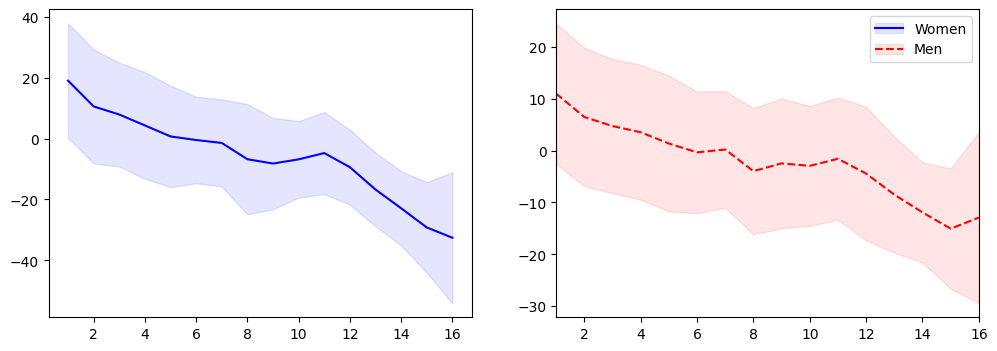

In [10]:
# let's see if __seed__ is predictive for predicting the point difference
tmpmean = tourney_data.pivot_table(
    columns="men_women", index="T1_seed", values="PointDiff", aggfunc="mean"
).ffill()
tmpstd = tourney_data.pivot_table(
    columns="men_women", index="T1_seed", values="PointDiff", aggfunc="std"
).ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(
    tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1
)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(
    tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1
)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

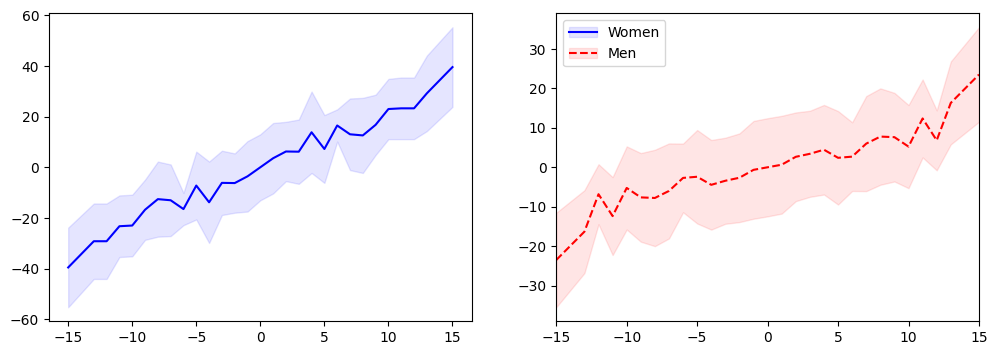

In [11]:
# let's see __seed difference__ is predictive for predicting the point difference
tmpmean = tourney_data.pivot_table(
    columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="mean"
).ffill()
tmpstd = tourney_data.pivot_table(
    columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="std"
).ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(
    tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1
)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(
    tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1
)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

## Medium Features

In [12]:
# box score columns, for which we want features to our model
boxcols = [
    "T1_Score",
    "T1_FGM",
    "T1_FGA",
    "T1_FGM3",
    "T1_FGA3",
    "T1_FTM",
    "T1_FTA",
    "T1_OR",
    "T1_DR",
    "T1_Ast",
    "T1_TO",
    "T1_Stl",
    "T1_Blk",
    "T1_PF",  # "T1_POSS",
    "T2_Score",
    "T2_FGM",
    "T2_FGA",
    "T2_FGM3",
    "T2_FGA3",
    "T2_FTM",
    "T2_FTA",
    "T2_OR",
    "T2_DR",
    "T2_Ast",
    "T2_TO",
    "T2_Stl",
    "T2_Blk",
    "T2_PF",  # "T2_POSS",
    "PointDiff",
]

1. Let's define a single match {T, OPP}. This means that T=TEAM(x) plays against an opponent team OPP=TEAM(y1)
2. During regular season, team T plays multiple games {T, OPP1}, {T, OPP2}, ...; against different opponents OPP1=TEAM(y1), OPP2=TEAM(y2), ...
3. We can calculate regular season average performance for the team T : average[T]
4. We can also calculate how opponents perform on average when they play a game against team T : average[T_OPP1,T_OPP2,...]
5. Let's play a new match: {T1, T2}¶
6. We can collect performance data for the T1: average[T1] and average[T1_OPP1,T1_OPP2,...]
7. We can collect performance data for the T2: average[T2] and average[T2_OPP1,T2_OPP2,...]
8. Then we can combine all data: average[T1],average[T1_OPP1,T1_OPP2,...], average[T2], average[T2_OPP1,T2_OPP2,...]
9. Use this data to predict the output of a match between T1 and T2¶

In [13]:
# calculate season averages
ss = regular_data.groupby(["Season", "T1_TeamID"])[boxcols].agg("mean").reset_index()

ss_T1 = ss.copy()
ss_T1.columns = [
    "T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_")
    for x in list(ss_T1.columns)
]
ss_T1 = ss_T1.rename({"T1_avg_Season": "Season", "T1_avg_TeamID": "T1_TeamID"}, axis=1)
ss_T2 = ss.copy()
ss_T2.columns = [
    "T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_")
    for x in list(ss_T2.columns)
]
ss_T2 = ss_T2.rename({"T2_avg_Season": "Season", "T2_avg_TeamID": "T2_TeamID"}, axis=1)

tourney_data = pd.merge(tourney_data, ss_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, ss_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff
0,2003,1421,1411,7.111111,1,1,16,16,0,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148
1,2003,1112,1436,29.000000,1,1,1,16,15,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655
2,2003,1113,1272,13.000000,1,1,10,7,-3,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487
3,2003,1141,1166,6.000000,1,1,11,6,-5,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990
4,2003,1143,1301,1.777778,1,1,8,9,1,73.636015,27.015326,57.946360,6.314176,16.789272,13.291188,19.371648,11.114943,24.095785,15.816092,14.019157,6.455939,2.758621,16.888889,68.923372,25.072797,58.114943,7.034483,21.237548,11.743295,17.214559,11.049808,22.659004,15.881226,14.708812,5.865900,2.482759,18.919540,4.712644,72.122222,24.248148,53.129630,7.940741,22.429630,15.685185,20.385185,9.700000,21.907407,14.614815,14.129630,7.737037,3.048148,18.603704,67.751852,23.337037,52.925926,5.703704,16.903704,15.374074,21.129630,10.514815,21.348148,12.511111,14.581481,7.418519,2.811111,19.262963,4.370370

## Hard Features

In [14]:
def update_elo(winner_elo, loser_elo):
    expected_win = expected_result(winner_elo, loser_elo)
    change_in_elo = k_factor * (1 - expected_win)
    winner_elo += change_in_elo
    loser_elo -= change_in_elo
    return winner_elo, loser_elo


def expected_result(elo_a, elo_b):
    return 1.0 / (1 + 10 ** ((elo_b - elo_a) / elo_width))


base_elo = 1000
elo_width = 400
k_factor = 100

elos = []
for season in sorted(set(seeds["Season"])):
    ss = regular_data.loc[regular_data["Season"] == season]
    ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
    teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
    elo = dict(zip(teams, [base_elo] * len(teams)))
    for i in range(ss.shape[0]):
        w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
        w_elo, l_elo = elo[w_team], elo[l_team]
        w_elo_new, l_elo_new = update_elo(w_elo, l_elo)
        elo[w_team] = w_elo_new
        elo[l_team] = l_elo_new
    elo = pd.DataFrame.from_dict(elo, orient="index").reset_index()
    elo = elo.rename({"index": "TeamID", 0: "elo"}, axis=1)
    elo["Season"] = season
    elos.append(elo)
elos = pd.concat(elos)

elos_T1 = elos.copy().rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
elos_T2 = elos.copy().rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
tourney_data = pd.merge(tourney_data, elos_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, elos_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["elo_diff"] = tourney_data["T1_elo"] - tourney_data["T2_elo"]

In [19]:
tourney_data.head()

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff,T1_elo,T2_elo,elo_diff,T1_elo_best,T2_elo_best,elo_best_diff
0,2003,1421,1411,7.111111,1,1,16,16,0,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148,1004.511285,1006.068840,-1.557555,584.108561,602.646988,-18.538426
1,2003,1112,1436,29.000000,1,1,1,16,15,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655,1428.100063,1163.408934,264.691130,2314.607631,918.754732,1395.852899
2,2003,1113,1272,13.000000,1,1,10,7,-3,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487,1169.181611,1344.907733,-175.726122,1647.840881,1809.331858,-161.490978
3,2003,1141,1166,6.000000,1,1,11,6,-5,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990,1358.162841,1382.642338,-24.479498,1549.847533,1812.275872,-262.428339
4,2003,1143,1301,1.777778,1,1,8,9,1,73.636015,27.015326,57.946360,6.314176,16.789272,13.291188,19.371648,11.114943,24.095785,15.816092,14.019157,6.455939,2.758621,16.888889,68.923372,25.072797,58.114943,7.034483,21.237548,11.743295,17.214559,11.049808,22.6590

In [17]:
m_elo_best = pd.read_csv(DATA_PATH / "mens_elo_best_rating.csv")
w_elo_best = pd.read_csv(DATA_PATH / "womens_elo_best_rating.csv")
mw_elo_best = pd.concat([m_elo_best, w_elo_best], ignore_index=True)

In [18]:
elos_best_T1 = mw_elo_best.copy().rename(
    {"TeamID": "T1_TeamID", "Rating_Last": "T1_elo_best"}, axis=1
)
elos_best_T2 = mw_elo_best.copy().rename(
    {"TeamID": "T2_TeamID", "Rating_Last": "T2_elo_best"}, axis=1
)
tourney_data = pd.merge(
    tourney_data,
    elos_best_T1[["Season", "T1_TeamID", "T1_elo_best"]],
    on=["Season", "T1_TeamID"],
    how="left",
)
tourney_data = pd.merge(
    tourney_data,
    elos_best_T2[["Season", "T2_TeamID", "T2_elo_best"]],
    on=["Season", "T2_TeamID"],
    how="left",
)
tourney_data["elo_best_diff"] = (
    tourney_data["T1_elo_best"] - tourney_data["T2_elo_best"]
)

<Axes: xlabel='elo'>

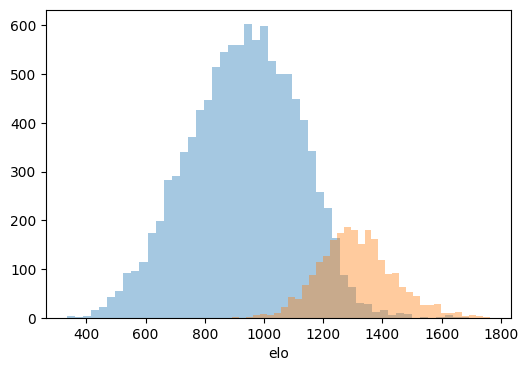

In [20]:
tmp = pd.merge(
    elos,
    tourney_data[["Season", "T1_TeamID"]].drop_duplicates(),
    left_on=["Season", "TeamID"],
    right_on=["Season", "T1_TeamID"],
    how="left",
)

plt.figure(figsize=(6, 4))
seaborn.distplot(tmp.loc[pd.isnull(tmp["T1_TeamID"]), "elo"], kde=False)
seaborn.distplot(tmp.loc[~pd.isnull(tmp["T1_TeamID"]), "elo"], kde=False)

<Axes: xlabel='T1_seed', ylabel='T1_elo'>

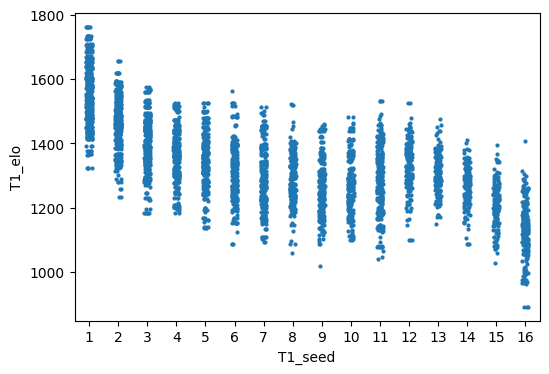

In [21]:
plt.figure(figsize=(6, 4))
seaborn.stripplot(data=tourney_data, y="T1_elo", x="T1_seed", size=3)

<Axes: xlabel='Seed_diff', ylabel='elo_diff'>

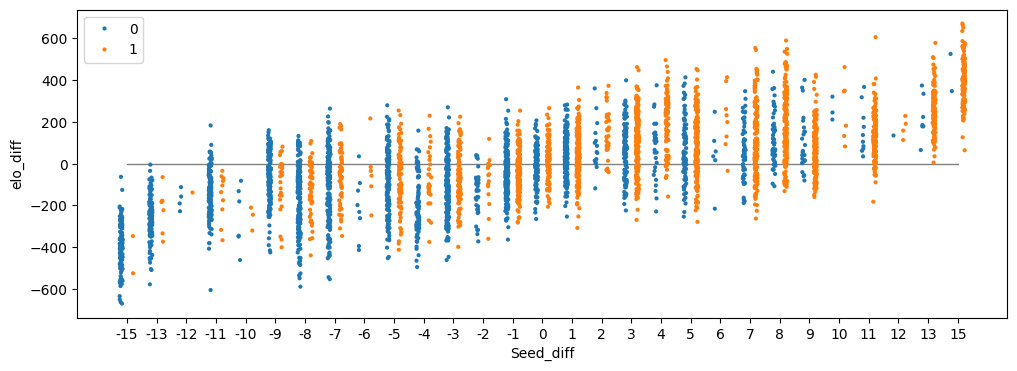

In [22]:
plt.figure(figsize=(12, 4))
seaborn.stripplot(
    data=tourney_data, y="elo_diff", x="Seed_diff", hue="win", dodge=True, size=3
)
seaborn.lineplot([0] * 29, color="gray", lw=1)

## Hardest Features

In [23]:
import statsmodels.api as sm
import tqdm
import numpy as np

# Create unique season/team identifiers
regular_data["ST1"] = regular_data.apply(
    lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1
)
regular_data["ST2"] = regular_data.apply(
    lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1
)
seeds_T1["ST1"] = seeds_T1.apply(
    lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1
)
seeds_T2["ST2"] = seeds_T2.apply(
    lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1
)

# Collect tournament teams
st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])

# Include non-tourney teams that defeated a tourney team at least once
st = st | set(
    regular_data.loc[
        (regular_data["T1_Score"] > regular_data["T2_Score"])
        & (regular_data["ST2"].isin(st)),
        "ST1",
    ]
)

# Add Home/Away column (1 = Home, -1 = Away, 0 = Neutral)
regular_data["Home_Away"] = np.where(
    regular_data["T1_Loc"] == "H", 1, np.where(regular_data["T1_Loc"] == "A", -1, 0)
)


def team_quality(season, men_women, use_logistic=False):
    """
    Compute team quality using GLM with home/away adjustments.
    Optionally use logistic regression instead of linear regression.
    """
    dt_season = dt.loc[(dt["Season"] == season) & (dt["men_women"] == men_women), :]

    # Choose the formula and model type
    if use_logistic:
        formula = "Win ~ -1 + T1_TeamID + T2_TeamID + Home_Away"
        glm = sm.GLM.from_formula(
            formula=formula,
            data=dt_season,
            family=sm.families.Binomial(),
        ).fit()
    else:
        formula = "PointDiff ~ -1 + T1_TeamID + T2_TeamID + Home_Away"
        glm = sm.GLM.from_formula(
            formula=formula,
            data=dt_season,
            family=sm.families.Gaussian(),
        ).fit()

    # Extract quality scores
    quality = pd.DataFrame(glm.params).reset_index()
    quality.columns = ["TeamID", "quality"]
    quality["Season"] = season

    # Keep only T1 team IDs
    quality = quality.loc[quality.TeamID.str.contains("T1_")].reset_index(drop=True)
    quality["TeamID"] = quality["TeamID"].apply(lambda x: x[10:14]).astype(int)

    return quality


# Filter relevant games
dt = regular_data.loc[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)]
dt["Win"] = (dt["T1_Score"] > dt["T2_Score"]).astype(
    int
)  # Convert game result to binary
dt["T1_TeamID"] = dt["T1_TeamID"].astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(str)
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"

glm_quality = []

seasons = sorted(set(seeds["Season"]))

# Compute team quality for each season
for s in tqdm.tqdm(seasons, unit="season"):
    if s >= 2010:  # min season for women
        glm_quality.append(team_quality(s, 0, use_logistic=False))
    if s >= 2003:  # min season for men
        glm_quality.append(team_quality(s, 1, use_logistic=False))

glm_quality = pd.concat(glm_quality).reset_index(drop=True)

# Create Rolling 3-Year Average for Quality
glm_quality["T1_quality_rolling"] = (
    glm_quality.groupby("TeamID")["quality"]
    .rolling(3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

# Merge into tournament dataset
glm_quality_T1 = glm_quality.copy()
glm_quality_T2 = glm_quality.copy()
glm_quality_T1.columns = ["T1_TeamID", "T1_quality", "Season", "T1_quality_rolling"]
glm_quality_T2.columns = ["T2_TeamID", "T2_quality", "Season", "T2_quality_rolling"]

tourney_data = pd.merge(
    tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left"
)
tourney_data = pd.merge(
    tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left"
)

# Compute new quality-based features
tourney_data["diff_quality"] = tourney_data["T1_quality"] - tourney_data["T2_quality"]
tourney_data["diff_quality_rolling"] = (
    tourney_data["T1_quality_rolling"] - tourney_data["T2_quality_rolling"]
)
tourney_data["quality_interaction"] = (
    tourney_data["T1_quality"] * tourney_data["T2_quality"]
)

100%|██████████| 22/22 [01:54<00:00,  5.21s/season]


In [24]:
tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff,T1_elo,T2_elo,elo_diff,T1_elo_best,T2_elo_best,elo_best_diff,T1_quality,T1_quality_rolling,T2_quality,T2_quality_rolling,diff_quality,diff_quality_rolling,quality_interaction
0,2003,1421,1411,7.111111,1,1,16,16,0,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148,1004.511285,1006.068840,-1.557555,584.108561,602.646988,-18.538426,-2.657641,-2.657641,1.919668,1.919668,-4.577309,-4.577309,-5.101787
1,2003,1112,1436,29.000000,1,1,1,16,15,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655,1428.100063,1163.408934,264.691130,2314.607631,918.754732,1395.852899,25.461036,25.461036,9.246110,9.246110,16.214926,16.214926,235.415544
2,2003,1113,1272,13.000000,1,1,10,7,-3,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487,1169.181611,1344.907733,-175.726122,1647.840881,1809.331858,-161.490978,17.151347,17.151347,16.668291,16.668291,0.483056,0.483056,285.883639
3,2003,1141,1166,6.000000,1,1,11,6,-5,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990,1358.16284

<Axes: ylabel='T1_quality'>

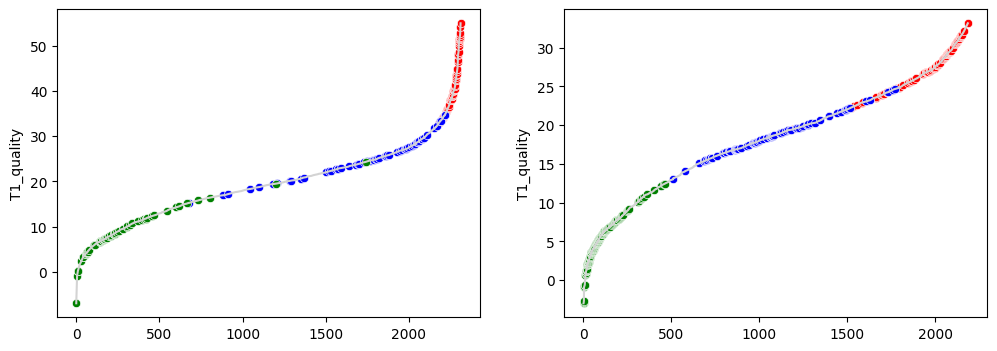

In [25]:
tmp = (
    tourney_data[["Season", "men_women", "T1_seed", "T1_quality"]]
    .drop_duplicates()
    .sort_values("T1_quality")
    .reset_index(drop=True)
)

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

seaborn.lineplot(
    tmp.loc[tmp["men_women"] == 0, "T1_quality"], color="lightgray", ax=axs[0]
)
seaborn.scatterplot(
    tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 1), "T1_quality"],
    color="red",
    ax=axs[0],
)
seaborn.scatterplot(
    tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 7), "T1_quality"],
    color="blue",
    ax=axs[0],
)
seaborn.scatterplot(
    tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 16), "T1_quality"],
    color="green",
    ax=axs[0],
)

seaborn.lineplot(
    tmp.loc[tmp["men_women"] == 1, "T1_quality"], color="lightgray", ax=axs[1]
)
seaborn.scatterplot(
    tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 1), "T1_quality"],
    color="red",
    ax=axs[1],
)
seaborn.scatterplot(
    tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 7), "T1_quality"],
    color="blue",
    ax=axs[1],
)
seaborn.scatterplot(
    tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 16), "T1_quality"],
    color="green",
    ax=axs[1],
)

In [26]:
tmp["QualitySeed"] = (
    (tmp.groupby(["Season", "men_women"])["T1_quality"].rank(ascending=False) // 4 + 1)
    .clip(1, 16)
    .astype(int)
)
pd.pivot_table(
    data=tmp,
    index="T1_seed",
    columns="QualitySeed",
    values="men_women",
    aggfunc="count",
).fillna(0).astype(int).style.bar(color="#5fba7d", vmin=0, vmax=50)

QualitySeed,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
T1_seed,,,,,,,,,,,,,,,,
1,79,39,14,4,1,2,1,0,0,0,0,0,0,0,0,0
2,15,56,39,18,7,4,1,0,0,0,0,0,0,0,0,0
3,5,15,34,31,32,9,5,4,2,1,2,0,0,0,0,0
4,5,17,21,23,21,19,19,7,5,0,3,0,0,0,0,0
5,0,6,13,24,19,24,21,13,6,9,3,2,0,0,0,0
6,1,2,8,18,19,26,17,15,13,10,5,5,1,0,0,0
7,0,2,5,7,13,17,17,21,19,18,11,7,3,0,0,0
8,0,0,3,4,7,17,18,17,21,19,19,9,3,3,0,0
9,0,2,0,5,11,7,11,17,15,32,21,12,4,2,1,0


In [27]:
from sklearn.metrics import roc_auc_score

print(
    "Seed AUC    :",
    np.round(
        roc_auc_score(
            1 - tourney_data["win"], tourney_data["T1_seed"] - tourney_data["T2_seed"]
        ),
        3,
    ),
)
print(
    "Quality AUC :",
    np.round(
        roc_auc_score(
            tourney_data["win"], tourney_data["T1_quality"] - tourney_data["T2_quality"]
        ),
        3,
    ),
)

Seed AUC    : 0.807
Quality AUC : 0.826


In [28]:
# who is better, experts or statistics, by season
for s in sorted(set(tourney_data["Season"])):
    st = tourney_data["Season"] == s
    print(
        s,
        a := np.round(
            roc_auc_score(
                1 - tourney_data.loc[st, "win"],
                tourney_data.loc[st, "T1_seed"] - tourney_data.loc[st, "T2_seed"],
            ),
            3,
        ),
        b := np.round(
            roc_auc_score(
                tourney_data.loc[st, "win"],
                tourney_data.loc[st, "T1_quality"] - tourney_data.loc[st, "T2_quality"],
            ),
            3,
        ),
        np.where(a > b, "", "Q"),
    )

2003 0.807 0.776 
2004 0.823 0.802 
2005 0.792 0.822 Q
2006 0.75 0.795 Q
2007 0.902 0.839 
2008 0.817 0.859 Q
2009 0.84 0.83 
2010 0.804 0.814 Q
2011 0.789 0.822 Q
2012 0.828 0.851 Q
2013 0.792 0.818 Q
2014 0.779 0.82 Q
2015 0.85 0.874 Q
2016 0.787 0.826 Q
2017 0.842 0.851 Q
2018 0.786 0.798 Q
2019 0.85 0.88 Q
2021 0.78 0.815 Q
2022 0.77 0.795 Q
2023 0.781 0.793 Q
2024 0.839 0.841 Q


## Export `tourney_data`

In [29]:
tourney_data.to_csv(
    DATA_PATH / "vilnius_ncaa_raddar_tourney_data_final_v3.csv", index=False
)

## Machine Learning Model

In [30]:
features = [
    ### EASY FEATURES ###
    "men_women",
    "T1_seed",
    "T2_seed",
    "Seed_diff",
    ### MEDIUM FEATURES ###
    "T1_avg_Score",
    # "T1_avg_FGM",
    "T1_avg_FGA",
    # "T1_avg_FGM3",
    # "T1_avg_FGA3",
    # "T1_avg_FTM",
    # "T1_avg_FTA",
    # "T1_avg_OR",
    # "T1_avg_DR",
    # "T1_avg_Ast",
    # "T1_avg_TO",
    # "T1_avg_Stl",
    "T1_avg_Blk",
    "T1_avg_PF",
    # "T1_avg_POSS",
    # "T1_avg_opponent_Score",
    # "T1_avg_opponent_FGM",
    "T1_avg_opponent_FGA",
    # "T1_avg_opponent_FGM3",
    # "T1_avg_opponent_FGA3",
    # "T1_avg_opponent_FTM",
    # "T1_avg_opponent_FTA",
    # "T1_avg_opponent_OR",
    # "T1_avg_opponent_DR",
    # "T1_avg_opponent_Ast",
    # "T1_avg_opponent_TO",
    # "T1_avg_opponent_Stl",
    "T1_avg_opponent_Blk",
    "T1_avg_opponent_PF",
    "T1_avg_PointDiff",
    "T2_avg_Score",
    # "T2_avg_FGM",
    "T2_avg_FGA",
    # "T2_avg_FGM3",
    # "T2_avg_FGA3",
    # "T2_avg_FTM",
    # "T2_avg_FTA",
    # "T2_avg_OR",
    # "T2_avg_DR",
    # "T2_avg_Ast",
    # "T2_avg_TO",
    # "T2_avg_Stl",
    "T2_avg_Blk",
    "T2_avg_PF",
    # "T2_avg_POSS",
    # "T2_avg_opponent_Score",
    # "T2_avg_opponent_FGM",
    "T2_avg_opponent_FGA",
    # "T2_avg_opponent_FGM3",
    # "T2_avg_opponent_FGA3",
    # "T2_avg_opponent_FTM",
    # "T2_avg_opponent_FTA",
    # "T2_avg_opponent_OR",
    # "T2_avg_opponent_DR",
    # "T2_avg_opponent_Ast",
    # "T2_avg_opponent_TO",
    # "T2_avg_opponent_Stl",
    "T2_avg_opponent_Blk",
    "T2_avg_opponent_PF",
    "T2_avg_PointDiff",
    ### HARD FEATURES ###
    "T1_elo",
    "T2_elo",
    "elo_diff",
    "T1_elo_best",
    "T2_elo_best",
    "elo_best_diff",
    ### HARDEST FEATURES ###
    "T1_quality",
    "T2_quality",
    # "diff_quality",
    # "diff_quality_rolling",
    # "quality_interaction",
]

print(f"Number of features {len(features)}")

Number of features 28


In [66]:
features = [
    ### EASY FEATURES ###
    "men_women",
    "T1_seed",
    "T2_seed",
    "Seed_diff",
    ### MEDIUM FEATURES ###
    "T1_avg_Score",
    "T1_avg_FGM",
    "T1_avg_FGA",
    "T1_avg_FGM3",
    "T1_avg_FGA3",
    "T1_avg_FTM",
    "T1_avg_FTA",
    "T1_avg_OR",
    "T1_avg_DR",
    "T1_avg_Ast",
    "T1_avg_TO",
    "T1_avg_Stl",
    "T1_avg_Blk",
    "T1_avg_PF",
    "T1_avg_opponent_Score",
    "T1_avg_opponent_FGM",
    "T1_avg_opponent_FGA",
    "T1_avg_opponent_FGM3",
    "T1_avg_opponent_FGA3",
    "T1_avg_opponent_FTM",
    "T1_avg_opponent_FTA",
    "T1_avg_opponent_OR",
    "T1_avg_opponent_DR",
    "T1_avg_opponent_Ast",
    "T1_avg_opponent_TO",
    "T1_avg_opponent_Stl",
    "T1_avg_opponent_Blk",
    "T1_avg_opponent_PF",
    "T1_avg_PointDiff",
    "T2_avg_Score",
    "T2_avg_FGM",
    "T2_avg_FGA",
    "T2_avg_FGM3",
    "T2_avg_FGA3",
    "T2_avg_FTM",
    "T2_avg_FTA",
    "T2_avg_OR",
    "T2_avg_DR",
    "T2_avg_Ast",
    "T2_avg_TO",
    "T2_avg_Stl",
    "T2_avg_Blk",
    "T2_avg_PF",
    "T2_avg_opponent_Score",
    "T2_avg_opponent_FGM",
    "T2_avg_opponent_FGA",
    "T2_avg_opponent_FGM3",
    "T2_avg_opponent_FGA3",
    "T2_avg_opponent_FTM",
    "T2_avg_opponent_FTA",
    "T2_avg_opponent_OR",
    "T2_avg_opponent_DR",
    "T2_avg_opponent_Ast",
    "T2_avg_opponent_TO",
    "T2_avg_opponent_Stl",
    "T2_avg_opponent_Blk",
    "T2_avg_opponent_PF",
    "T2_avg_PointDiff",
    ### HARD FEATURES ###
    "T1_elo",
    "T2_elo",
    "elo_diff",
    ### HARDEST FEATURES ###
    "T1_quality",
    "T2_quality",
    "diff_quality",
    "diff_quality_rolling",
    "quality_interaction",
]

print(f"Number of features {len(features)}")

Number of features 67


In [31]:
import xgboost as xgb

param = {}
param["objective"] = "reg:squarederror"
param["booster"] = "gbtree"
param["eta"] = 0.01
param["subsample"] = 0.6
param["colsample_bynode"] = 0.8
param["num_parallel_tree"] = 2
param["min_child_weight"] = 4
param["max_depth"] = 4
param["tree_method"] = "hist"
param["grow_policy"] = "lossguide"
param["max_bin"] = 32

num_rounds = 700

In [32]:
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, brier_score_loss
import numpy as np

models = {}
oof_mae = []
oof_preds = []
oof_targets = []
oof_ss = []

# Leave-one-season-out training
for oof_season in set(tourney_data.Season):
    x_train = tourney_data.loc[tourney_data["Season"] != oof_season, features]
    y_train = tourney_data.loc[tourney_data["Season"] != oof_season, "PointDiff"]
    x_val = tourney_data.loc[tourney_data["Season"] == oof_season, features]
    y_val = tourney_data.loc[tourney_data["Season"] == oof_season, "PointDiff"]
    s_val = tourney_data.loc[tourney_data["Season"] == oof_season, "Season"].values

    # Use XGBRegressor instead of xgb.train
    model = XGBRegressor(
        objective="reg:squarederror",
        booster="gbtree",
        eta=0.01,
        subsample=0.6,
        colsample_bynode=0.8,
        num_parallel_tree=2,
        min_child_weight=4,
        max_depth=4,
        tree_method="hist",
        grow_policy="lossguide",
        max_bin=32,
        n_estimators=700,  # Equivalent to num_boost_round
    )

    model.fit(x_train, y_train)
    models[oof_season] = model  # Store trained model

    # Get validation predictions
    preds = model.predict(x_val)
    print(f"oof season {oof_season} MAE: {np.mean(np.abs(y_val - preds))}")
    oof_mae.append(mean_absolute_error(y_val, preds))
    oof_preds += list(preds)
    oof_targets += list(y_val)
    oof_ss += list(s_val)

print(f"average mae: {np.mean(oof_mae)}")

oof season 2003 MAE: 8.567866936783927
oof season 2004 MAE: 8.034722467964619
oof season 2005 MAE: 8.0286426095887
oof season 2006 MAE: 8.506360100875867
oof season 2007 MAE: 7.9255066107446
oof season 2008 MAE: 9.410397504994762
oof season 2009 MAE: 9.50156363364917
oof season 2010 MAE: 8.821921340705321
oof season 2011 MAE: 9.853094962289095
oof season 2012 MAE: 8.132982982739678
oof season 2013 MAE: 9.85882115753861
oof season 2014 MAE: 9.8658288722428
oof season 2015 MAE: 8.019838446254532
oof season 2016 MAE: 9.789329603519093
oof season 2017 MAE: 9.834071617325149
oof season 2018 MAE: 10.198782196623457
oof season 2019 MAE: 9.350048195586627
oof season 2021 MAE: 10.17710192111689
oof season 2022 MAE: 10.080988112260366
oof season 2023 MAE: 9.587020108516437
oof season 2024 MAE: 9.211080419261064
average mae: 9.17885570478956


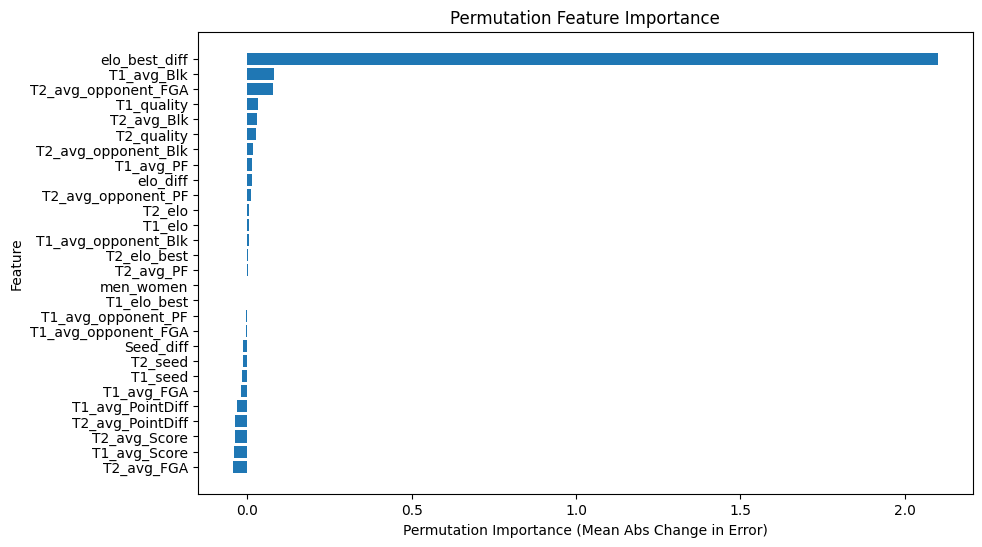

In [33]:
# Select a season to evaluate feature importance
oof_season = list(models.keys())[0]
model = models[oof_season]  # Get trained model

x_val = tourney_data.loc[tourney_data["Season"] == oof_season, features]
y_val = tourney_data.loc[tourney_data["Season"] == oof_season, "PointDiff"]

# Compute permutation importance
r = permutation_importance(
    model,
    x_val,
    y_val,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
)

# Convert to DataFrame
perm_importance_df = pd.DataFrame(
    {"Feature": features, "Importance": r.importances_mean}
)
perm_importance_df = perm_importance_df.sort_values(by="Importance", ascending=False)

# Plot Feature Importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df["Feature"], perm_importance_df["Importance"])
plt.xlabel("Permutation Importance (Mean Abs Change in Error)")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
pd.set_option("display.max_rows", 100)
perm_importance_df

<Axes: xlabel='pred_pointdiff', ylabel='average_win_pct'>

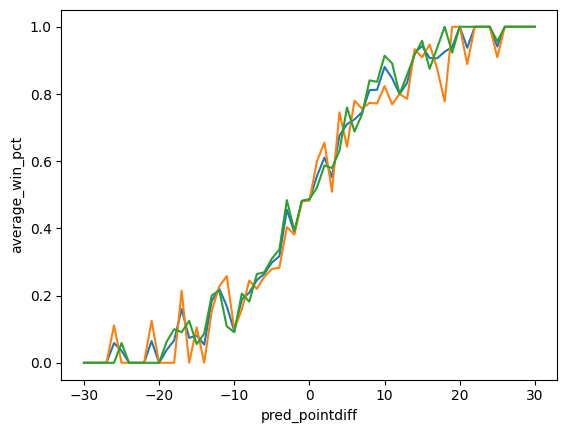

In [34]:
df = pd.DataFrame(
    {
        "Season": oof_ss,
        "pred": oof_preds,
        "label": [(t > 0) * 1 for t in oof_targets],
        "men_women": tourney_data["men_women"],
    }
)
df["pred_pointdiff"] = df["pred"].astype(int)

xdf_all = (
    df.clip(-30, 30)
    .groupby("pred_pointdiff")["label"]
    .mean()
    .reset_index(name="average_win_pct")
)
xdf_men = (
    df.clip(-30, 30)
    .loc[df["men_women"] == 0]
    .groupby("pred_pointdiff")["label"]
    .mean()
    .reset_index(name="average_win_pct")
)
xdf_women = (
    df.clip(-30, 30)
    .loc[df["men_women"] == 1]
    .groupby("pred_pointdiff")["label"]
    .mean()
    .reset_index(name="average_win_pct")
)

seaborn.lineplot(x=xdf_all["pred_pointdiff"], y=xdf_all["average_win_pct"])
seaborn.lineplot(x=xdf_men["pred_pointdiff"], y=xdf_men["average_win_pct"])
seaborn.lineplot(x=xdf_women["pred_pointdiff"], y=xdf_women["average_win_pct"])

brier: 0.1682537341853639


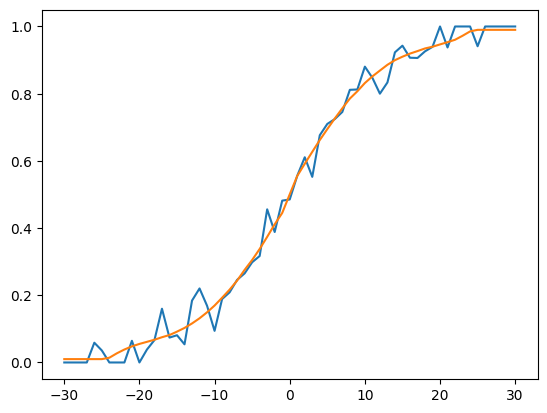

In [35]:
from scipy.interpolate import UnivariateSpline

t = 25
dat = list(zip(oof_preds, np.array(oof_targets) > 0))
dat = sorted(dat, key=lambda x: x[0])
pred, label = list(zip(*dat))
spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k=5)
spline_fit = np.clip(spline_model(np.clip(oof_preds, -t, t)), 0.01, 0.99)
print(f"brier: {brier_score_loss(np.array(oof_targets) > 0, spline_fit)}")
df["spline"] = spline_fit
xdf = (
    df.clip(-30, 30).groupby("pred_pointdiff")[["spline", "label"]].mean().reset_index()
)

plt.figure()
plt.plot(xdf["pred_pointdiff"], xdf["label"])
plt.plot(xdf["pred_pointdiff"], xdf["spline"])

In [36]:
print(f"brier: {brier_score_loss(np.array(oof_targets) > 0, spline_fit)}")

for oof_season in set(tourney_data.Season):
    x = df.loc[df["Season"] == oof_season, "spline"].values
    y = df.loc[df["Season"] == oof_season, "label"].values
    print(oof_season, np.round(brier_score_loss(y, x), 5))

brier: 0.1682537341853639
2003 0.17872
2004 0.18008
2005 0.17329
2006 0.19528
2007 0.152
2008 0.15368
2009 0.17082
2010 0.16764
2011 0.18192
2012 0.15072
2013 0.17222
2014 0.17402
2015 0.14345
2016 0.17437
2017 0.15517
2018 0.1766
2019 0.14497
2021 0.18282
2022 0.17751
2023 0.18517
2024 0.1558


## Make Submission

### Stage 1

In [41]:
##################################################################################
#### Stage2 data should be available on March 17, check forums for updates #######
##################################################################################

# X = pd.read_csv(f"{data_dir}/SampleSubmissionStage2.csv")
X = pd.read_csv(KAGGLE_DATA_PATH / "SampleSubmissionStage1.csv")
X

,ID,Pred
0,2021_1101_1102,0.5
1,2021_1101_1103,0.5
2,2021_1101_1104,0.5
3,2021_1101_1105,0.5
4,2021_1101_1106,0.5
...,...,...
507103,2024_3475_3477,0.5
507104,2024_3475_3478,0.5
507105,2024_3476_3477,0.5
507106,2024_3476_3478,0.5


In [43]:
# construct dataframe for submission
X["Season"] = X["ID"].apply(lambda t: int(t.split("_")[0]))
X["T1_TeamID"] = X["ID"].apply(lambda t: int(t.split("_")[1]))
X["T2_TeamID"] = X["ID"].apply(lambda t: int(t.split("_")[2]))
X["men_women"] = X["T1_TeamID"].apply(lambda t: 0 if str(t)[0] == "1" else 1)
X = pd.merge(X, ss_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, ss_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, seeds_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, seeds_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, elos_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, elos_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, elos_best_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, elos_best_T2, on=["Season", "T2_TeamID"], how="left")
X["Seed_diff"] = X["T2_seed"] - X["T1_seed"]
X["elo_diff"] = X["T1_elo"] - X["T2_elo"]
X["elo_best_diff"] = X["T1_elo"] - X["T2_elo"]
X["diff_quality"] = X["T1_quality"] - X["T2_quality"]
X["diff_quality_rolling"] = X["T1_quality_rolling"] - X["T2_quality_rolling"]
X["quality_interaction"] = X["T1_quality"] * X["T2_quality"]

In [44]:
# run models on given dataset
preds = []
for oof_season in set(tourney_data.Season):
    dtest = xgb.DMatrix(X[features].values)
    # margin_preds = models[oof_season].predict(dtest) * 1.0 # aggressive submissions >1, conservative submissions <1
    margin_preds = (
        models[oof_season].predict(X[features].values) * 1.0
    )  # aggressive submissions >1, conservative submissions <1
    probs = np.clip(spline_model(np.clip(margin_preds, -t, t)), 0.01, 0.99)
    preds.append(probs)
X["Pred"] = np.array(preds).mean(axis=0)

In [45]:
# sanity check to check for seed matchup win probability distribution
pd.pivot_table(
    data=X, index="T1_seed", columns="T2_seed", values="Pred", aggfunc="mean"
).style.bar(color="#5fba7d", vmin=0, vmax=1)

T2_seed,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.000000,11.000000,12.000000,13.000000,14.000000,15.000000,16.000000
T1_seed,,,,,,,,,,,,,,,,
1.000000,0.494803,0.617612,0.697662,0.741436,0.745500,0.725751,0.746253,0.738074,0.780403,0.791477,0.778565,0.792266,0.845769,0.880913,0.893023,0.929280
2.000000,0.435428,0.519027,0.586545,0.656396,0.671612,0.648049,0.669285,0.690950,0.751157,0.705261,0.710967,0.696345,0.793785,0.834765,0.850939,0.903205
3.000000,0.315939,0.406613,0.525809,0.541247,0.575309,0.512526,0.551430,0.592962,0.637168,0.636151,0.622609,0.636268,0.615833,0.778805,0.759437,0.862021
4.000000,0.264918,0.390097,0.471858,0.525534,0.531956,0.505864,0.531450,0.577225,0.610979,0.594913,0.598203,0.603884,0.632166,0.718396,0.742075,0.842376
5.000000,0.255309,0.368040,0.460236,0.499432,0.508235,0.487918,0.514038,0.561777,0.576889,0.572825,0.572311,0.606066,0.633121,0.692768,0.694527,0.810060
6.000000,0.260587,0.388398,0.448421,0.497894,0.499559,0.506358,0.498229,0.547125,0.585938,0.570509,0.572596,0.600053,0.631232,0.690725,0.679926,0.779051
7.000000,0.217036,0.353708,0.448826,0.496255,0.508168,0.460284,0.498119,0.536822,0.570490,0.586092,0.583873,0.581318,0.601202,0.691277,0.676187,0.752591
8.000000,0.200344,0.342054,0.415983,0.466309,0.474912,0.457285,0.470520,0.497464,0.529643,0.536958,0.550790,0.556163,0.590129,0.647671,0.667915,0.713547
9.000000,0.189128,0.317700,0.380578,0.426971,0.448129,0.425788,0.440388,0.470894,0.531837,0.517947,0.528979,0.546547,0.574090,0.634368,0.641188,0.709775


In [46]:
X[["ID", "Pred"]].to_csv(SUBMISSION_DATA_PATH / "Elo_HCA_submission.csv", index=False)

### Stage 2

In [42]:
##################################################################################
#### Stage2 data should be available on March 17, check forums for updates #######
##################################################################################

# X = pd.read_csv(f"{data_dir}/SampleSubmissionStage2.csv")
X = pd.read_csv(KAGGLE_DATA_PATH / "SampleSubmissionStage2.csv")
X

,ID,Pred
0,2025_1101_1102,0.5
1,2025_1101_1103,0.5
2,2025_1101_1104,0.5
3,2025_1101_1105,0.5
4,2025_1101_1106,0.5
...,...,...
131402,2025_3477_3479,0.5
131403,2025_3477_3480,0.5
131404,2025_3478_3479,0.5
131405,2025_3478_3480,0.5


In [65]:
# construct dataframe for submission
X["Season"] = X["ID"].apply(lambda t: int(t.split("_")[0]))
X["T1_TeamID"] = X["ID"].apply(lambda t: int(t.split("_")[1]))
X["T2_TeamID"] = X["ID"].apply(lambda t: int(t.split("_")[2]))
X["men_women"] = X["T1_TeamID"].apply(lambda t: 0 if str(t)[0] == "1" else 1)
X = pd.merge(X, ss_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, ss_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, seeds_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, seeds_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, elos_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, elos_T2, on=["Season", "T2_TeamID"], how="left")
X["Seed_diff"] = X["T2_seed"] - X["T1_seed"]
X["elo_diff"] = X["T1_elo"] - X["T2_elo"]
X["diff_quality"] = X["T1_quality"] - X["T2_quality"]

In [66]:
# run models on given dataset
preds = []
for oof_season in set(tourney_data.Season):
    dtest = xgb.DMatrix(X[features].values)
    margin_preds = (
        models[oof_season].predict(dtest) * 1.0
    )  # aggressive submissions >1, conservative submissions <1
    probs = np.clip(spline_model(np.clip(margin_preds, -t, t)), 0.01, 0.99)
    preds.append(probs)
X["Pred"] = np.array(preds).mean(axis=0)

TypeError: Not supported type for data.<class 'xgboost.core.DMatrix'>

In [40]:
# sanity check to check for seed matchup win probability distribution
pd.pivot_table(
    data=X, index="T1_seed", columns="T2_seed", values="Pred", aggfunc="mean"
).style.bar(color="#5fba7d", vmin=0, vmax=1)

T2_seed,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.000000,11.000000,12.000000,13.000000,14.000000,15.000000,16.000000
T1_seed,,,,,,,,,,,,,,,,
1.000000,0.495889,0.683476,0.744622,0.801601,0.840132,0.830351,0.851323,0.875671,0.885773,0.909514,0.911772,0.952072,0.978104,0.988337,0.989529,0.990000
2.000000,0.342757,0.553154,0.647180,0.714819,0.776139,0.764073,0.766487,0.802552,0.871406,0.833003,0.848341,0.871490,0.952228,0.961400,0.972866,0.986659
3.000000,0.177180,0.369707,0.521906,0.601069,0.656299,0.641496,0.687533,0.741346,0.750772,0.791467,0.788236,0.841407,0.871609,0.957950,0.949778,0.983452
4.000000,0.136277,0.322556,0.418374,0.540939,0.600702,0.600731,0.638636,0.707433,0.720966,0.716301,0.760023,0.797846,0.869834,0.916940,0.950469,0.979311
5.000000,0.116198,0.283643,0.368779,0.453723,0.504442,0.533068,0.583371,0.654947,0.670975,0.671815,0.668976,0.766790,0.839653,0.881464,0.883362,0.964058
6.000000,0.121944,0.295109,0.341231,0.433777,0.459183,0.502309,0.549031,0.618568,0.665814,0.663631,0.671116,0.733235,0.830385,0.877756,0.891600,0.932304
7.000000,0.081580,0.283504,0.340238,0.412896,0.452142,0.410667,0.507785,0.600469,0.616217,0.656596,0.667776,0.709744,0.762724,0.867175,0.876691,0.925592
8.000000,0.075747,0.255630,0.309887,0.365808,0.385077,0.375158,0.427002,0.493673,0.539731,0.577886,0.614071,0.659834,0.733672,0.794990,0.846288,0.875756
9.000000,0.065073,0.205075,0.267311,0.329339,0.351639,0.341454,0.388870,0.457812,0.512054,0.566193,0.590278,0.659498,0.734441,0.792160,0.809050,0.880054


In [ ]:
X[["ID", "Pred"]].to_csv(
    SUBMISSION_DATA_PATH / "vilnius_ncaa_raddar_stage2.csv", index=False
)

## Feature Importance

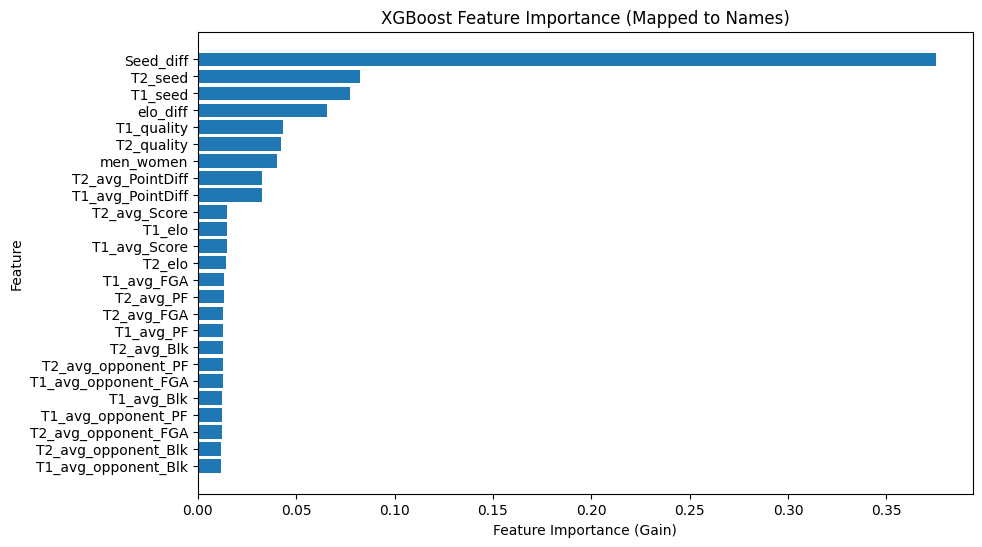

In [60]:
# XGBoost Built-in Feature Importance

import matplotlib.pyplot as plt
import pandas as pd

# Select one trained model (any season)
model = models[list(models.keys())[0]]  # Pick any trained model

# Extract feature importance from XGBRegressor
importance_values = model.feature_importances_

# Create DataFrame with actual feature names
importance_df = pd.DataFrame(
    {
        "Feature": features,  # Use actual feature names
        "Importance": importance_values,
    }
).sort_values(by="Importance", ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Feature Importance (Gain)")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance (Mapped to Names)")
plt.gca().invert_yaxis()
plt.show()

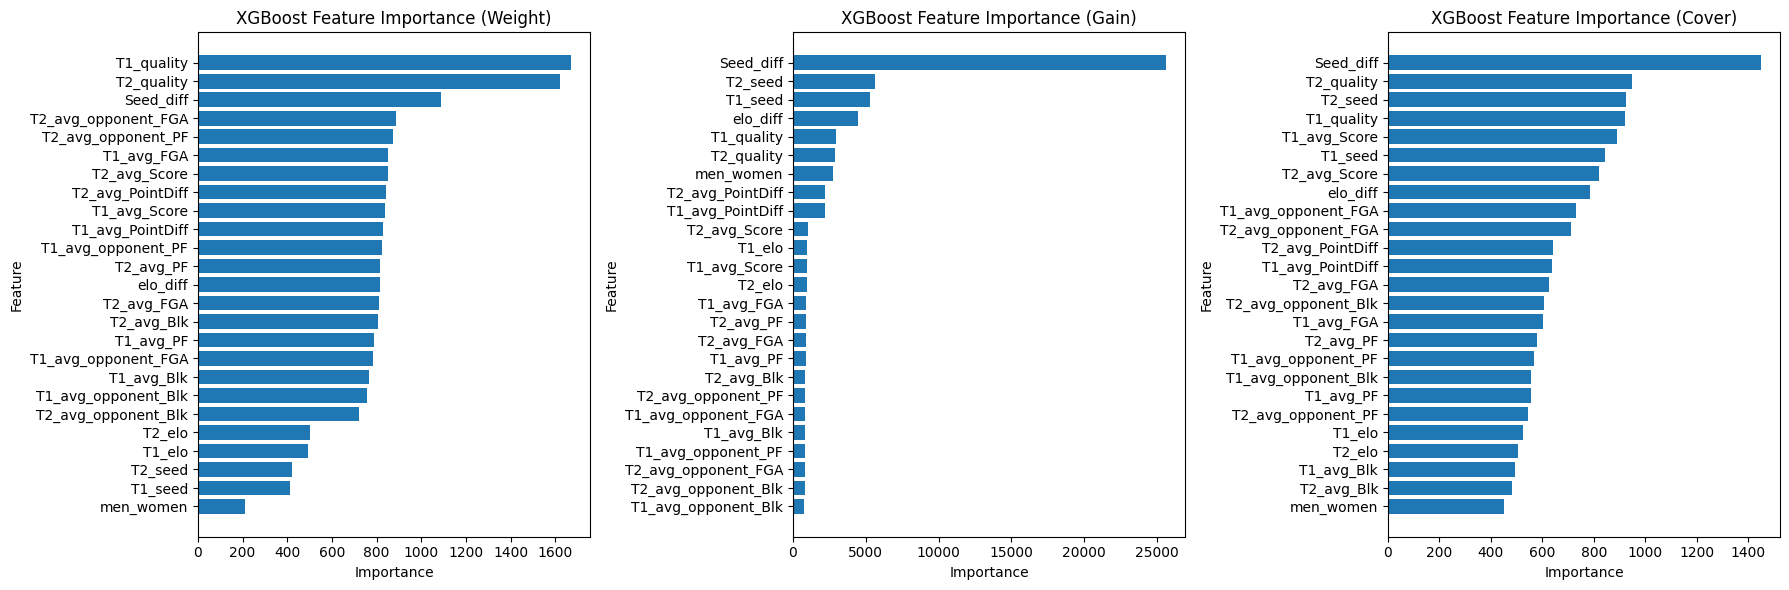

In [65]:
import matplotlib.pyplot as plt
import pandas as pd

# Select one trained model (any season)
model = models[list(models.keys())[0]]
booster = model.get_booster()

# Define importance types
importance_types = ["weight", "gain", "cover"]
importance_data = {}

for imp_type in importance_types:
    importance_dict = booster.get_score(importance_type=imp_type)

    # Convert dictionary to DataFrame
    importance_df = pd.DataFrame(
        {
            "Feature": list(importance_dict.keys()),  # Actual feature names
            "Importance": list(importance_dict.values()),
        }
    ).sort_values(by="Importance", ascending=False)

    importance_data[imp_type] = importance_df  # Store for plotting

# Plot Feature Importance for each type
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, imp_type in enumerate(importance_types):
    ax = axes[idx]
    df = importance_data[imp_type]

    if df.empty:  # Handle case where no data exists
        ax.set_title(f"No data for {imp_type.capitalize()}")
        ax.axis("off")
        continue

    ax.barh(df["Feature"], df["Importance"])
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    ax.set_title(f"XGBoost Feature Importance ({imp_type.capitalize()})")
    ax.invert_yaxis()  # Highest importance at top

plt.tight_layout()
plt.show()

📊 **What to Look For in the Plots**

* High Weight, Low Gain → The feature is used often but doesn’t improve the model much.
* High Gain, Low Weight → The feature is used in fewer splits but has a large impact on accuracy.
* High Cover, High Gain → The best features! These influence many samples and improve predictions.

!pip install shap

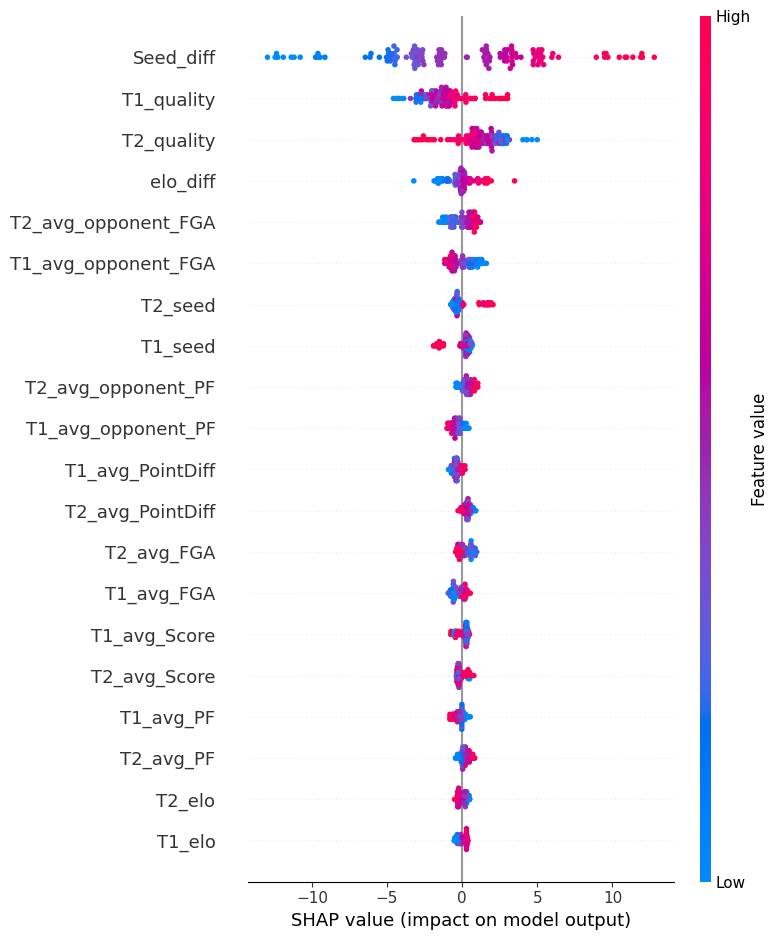

In [52]:
# SHAP (SHapley Additive exPlanations)

import shap

explainer = shap.Explainer(models[oof_season])
shap_values = explainer(x_val)

# Summary plot
shap.summary_plot(shap_values, x_val)

<Figure size 640x480 with 0 Axes>

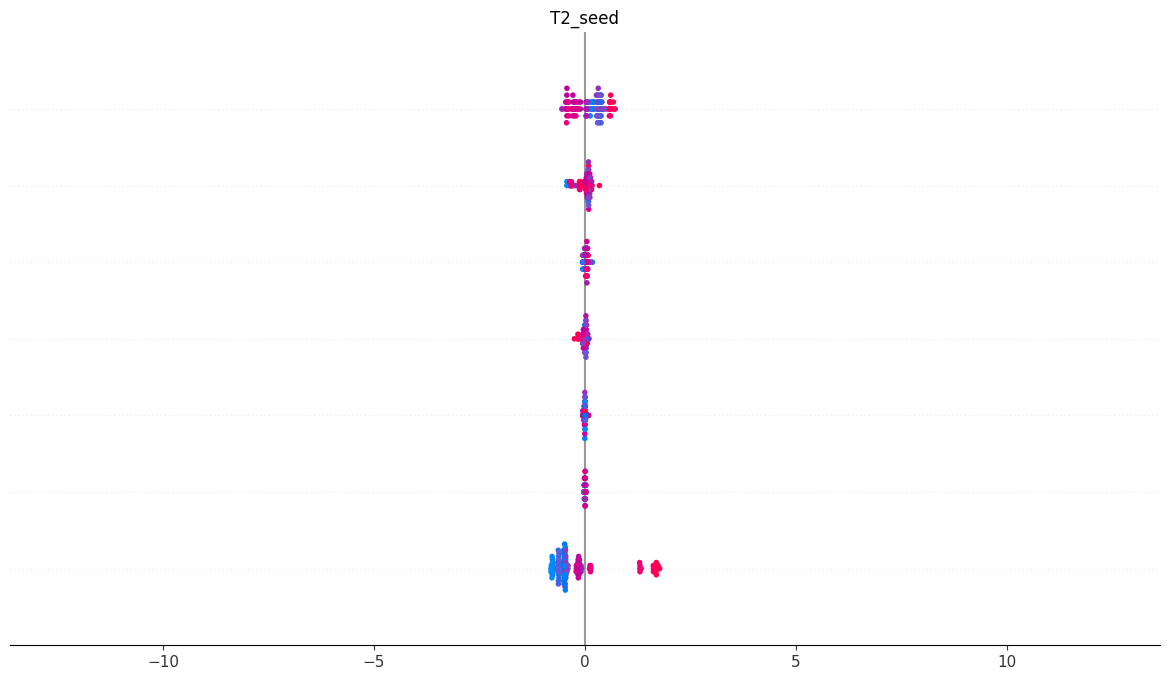

In [53]:
# SHAP Interaction Values

shap_interaction_values = explainer.shap_interaction_values(x_val)
shap.summary_plot(shap_interaction_values, x_val)

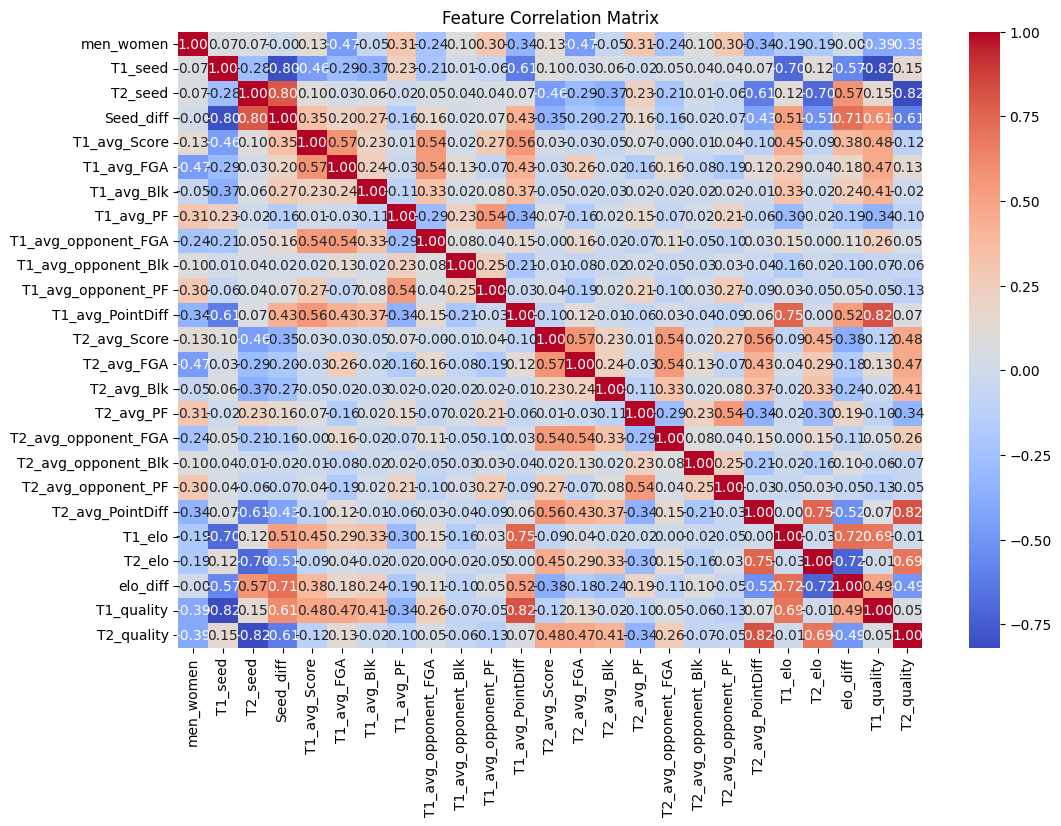

In [54]:
# Pairwise Correlation Analysis

import seaborn as sns

corr_matrix = tourney_data[features].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

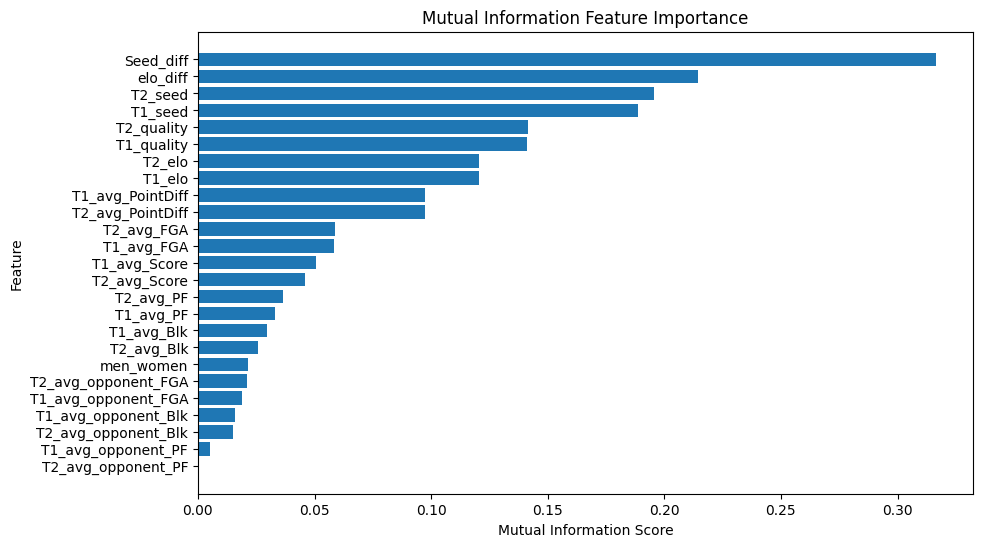

In [55]:
# Mutual Information (Non-Linear Dependencies)

from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(tourney_data[features], tourney_data["PointDiff"])
mi_scores_df = pd.DataFrame({"Feature": features, "Mutual_Info": mi_scores})
mi_scores_df = mi_scores_df.sort_values(by="Mutual_Info", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(mi_scores_df["Feature"], mi_scores_df["Mutual_Info"])
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Mutual Information Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## Feature Selection

In [47]:
from sklearn.feature_selection import RFECV
from xgboost import XGBRegressor

# Define initial model
model = XGBRegressor(
    objective="reg:squarederror",
    booster="gbtree",
    eta=0.01,
    subsample=0.6,
    colsample_bynode=0.8,
    num_parallel_tree=2,
    min_child_weight=4,
    max_depth=4,
    tree_method="hist",
    grow_policy="lossguide",
    max_bin=32,
    n_estimators=700,
)

# Perform Recursive Feature Elimination with Cross-Validation (RFECV)
selector = RFECV(model, step=1, scoring="neg_mean_absolute_error", cv=5)
selector.fit(tourney_data[features], tourney_data["PointDiff"])

# Get the selected features
optimal_features = [features[i] for i in range(len(features)) if selector.support_[i]]

print(f"Optimal number of features: {selector.n_features_}")
print(f"Selected features: {optimal_features}")

Optimal number of features: 1
Selected features: ['diff_quality']


In [75]:
from sklearn.inspection import permutation_importance

# Train model on all features
model.fit(tourney_data[features], tourney_data["PointDiff"])

# Compute permutation importance
r = permutation_importance(
    model,
    tourney_data[features],
    tourney_data["PointDiff"],
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
)

# Store results in a DataFrame
perm_importance_df = pd.DataFrame(
    {"Feature": features, "Importance": r.importances_mean}
)
perm_importance_df = perm_importance_df.sort_values(by="Importance", ascending=False)

# Select features above a threshold
threshold = 0.001  # Adjust as needed
selected_features = perm_importance_df.loc[
    perm_importance_df["Importance"] > threshold, "Feature"
].tolist()

print(f"Optimal features based on permutation importance: {selected_features}")

Optimal features based on permutation importance: ['Seed_diff', 'T2_quality', 'T1_quality', 'elo_diff', 'T1_avg_PointDiff', 'T1_seed', 'T2_avg_PointDiff', 'T2_seed', 'T1_avg_opponent_DR', 'T2_avg_OR', 'T2_avg_opponent_DR', 'T1_avg_Blk', 'T2_avg_opponent_OR', 'T1_avg_opponent_FGA', 'T1_avg_Score', 'T2_avg_Score', 'T1_avg_opponent_OR', 'T1_avg_OR', 'T2_avg_opponent_FGA', 'T2_avg_Blk', 'T2_avg_opponent_PF', 'T2_avg_FGA', 'T1_avg_opponent_Stl', 'T2_avg_FGM', 'T2_avg_opponent_Stl', 'T1_avg_opponent_PF', 'T1_avg_FGA', 'T1_avg_FGM', 'T2_avg_opponent_Blk', 'men_women', 'T1_avg_opponent_Blk', 'T2_avg_Ast', 'T1_avg_opponent_TO', 'T1_avg_Ast', 'T2_avg_opponent_TO', 'T1_avg_PF', 'T2_avg_opponent_Score', 'T1_avg_opponent_Score', 'T2_avg_FTA', 'T2_avg_PF', 'T1_avg_Stl', 'T2_avg_opponent_FGM3', 'T2_avg_Stl', 'T1_avg_opponent_FTA', 'T1_avg_FTM', 'T2_avg_FTM', 'T1_avg_FTA', 'T2_avg_FGA3', 'T1_avg_opponent_Ast', 'T1_avg_DR', 'T1_avg_opponent_FGM3', 'T2_avg_FGM3', 'T2_avg_DR', 'T2_elo', 'T2_avg_opponent_

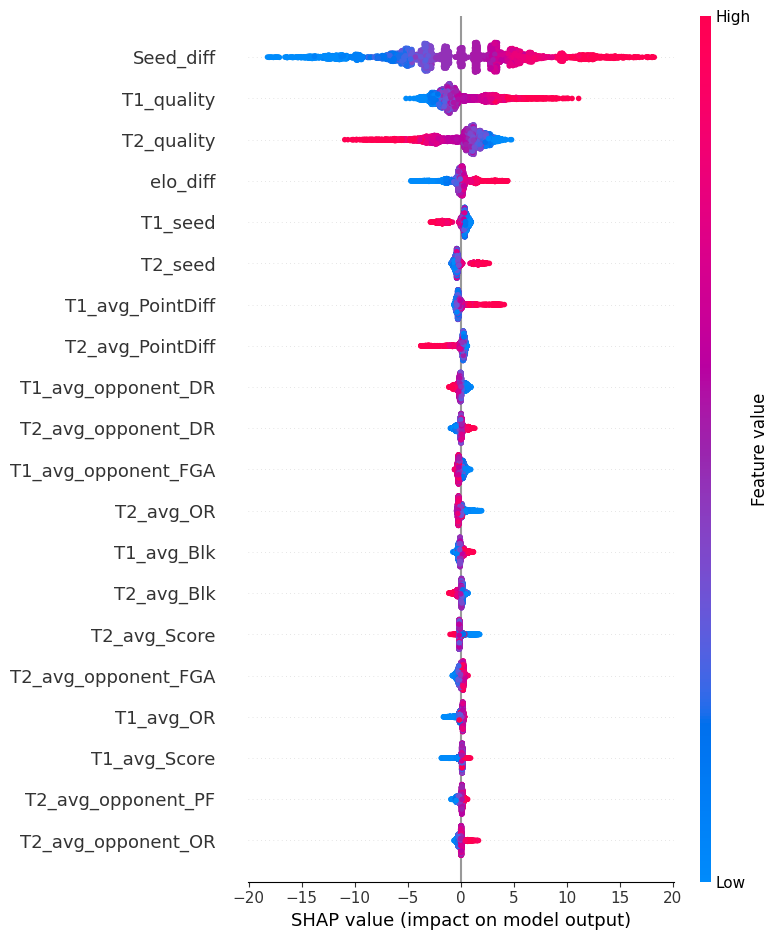

Optimal features based on SHAP: ['Seed_diff', 'T1_quality', 'T2_quality', 'elo_diff', 'T1_seed', 'T2_seed', 'T1_avg_PointDiff', 'T2_avg_PointDiff', 'T1_avg_opponent_DR', 'T2_avg_opponent_DR', 'T1_avg_opponent_FGA', 'T2_avg_OR', 'T1_avg_Blk', 'T2_avg_Blk', 'T2_avg_Score', 'T2_avg_opponent_FGA', 'T1_avg_OR', 'T1_avg_Score', 'T2_avg_opponent_PF', 'T2_avg_opponent_OR', 'T1_avg_opponent_PF', 'T2_avg_opponent_Stl', 'T1_avg_opponent_OR', 'T2_avg_FGM', 'T1_avg_opponent_Stl', 'T1_avg_FGM', 'T1_avg_FGA', 'T2_avg_FGA', 'men_women', 'T2_avg_opponent_Blk', 'T2_elo', 'T2_avg_opponent_Score', 'T1_elo', 'T1_avg_opponent_TO', 'T1_avg_opponent_Score', 'T1_avg_opponent_Blk', 'T2_avg_opponent_TO', 'T1_avg_Stl', 'T2_avg_Stl', 'T2_avg_PF', 'T1_avg_Ast', 'T2_avg_Ast', 'T1_avg_PF', 'T2_avg_opponent_FGM3', 'T2_avg_FTA', 'T1_avg_FTA', 'T1_avg_opponent_FTA', 'T1_avg_opponent_FTM', 'T2_avg_DR', 'T1_avg_opponent_FGM3', 'T2_avg_opponent_FTA', 'T2_avg_FTM', 'T2_avg_opponent_FTM', 'T2_avg_TO', 'T1_avg_FTM', 'T1_avg_D

In [76]:
import shap

# Create SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(tourney_data[features])

# Summarize feature importance
shap.summary_plot(shap_values, tourney_data[features])

# Select features with high SHAP impact
mean_shap_values = abs(shap_values.values).mean(axis=0)
shap_importance_df = pd.DataFrame({"Feature": features, "Mean SHAP": mean_shap_values})
shap_importance_df = shap_importance_df.sort_values(by="Mean SHAP", ascending=False)

# Keep features with high SHAP impact
selected_features = shap_importance_df.loc[
    shap_importance_df["Mean SHAP"] > 0.01, "Feature"
].tolist()

print(f"Optimal features based on SHAP: {selected_features}")